In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
import sys
import metpy
import matplotlib
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import metpy.calc as mpcalc
import pandas as pd
from netCDF4 import Dataset
import pyproj
import os
import glob
from datetime import datetime
import seaborn as sns
import netCDF4
from netCDF4 import Dataset
from metpy.units import units
import dask
import xarray as xr
from shapely import Polygon
import regionmask
import geopandas as gpd
import logging
import dask
from dask.distributed import Client
from dask import delayed
import functools
import zipfile
import tempfile
import wradlib as wrl
sys.path.append(os.path.join(r"/home/563/ac9768/GBR/scripts/Paper_figures")) 
# from define_wind_regimes import wind_times

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
barra_towns = xr.open_dataset("/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa_winds_townsville.nc", engine="h5netcdf",chunks="auto")
barra_cairns = xr.open_dataset("/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa_winds_cairns.nc", engine="h5netcdf",chunks="auto")
barra_willis = xr.open_dataset("/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa_winds_willis_island.nc", engine="h5netcdf",chunks="auto")

In [4]:
from dask_setup import setup_dask_client 
from dask_setup import recommend_chunks
client, cluster, dask_tmp = setup_dask_client(mode="interactive", workload_type="cpu") # 'io','mixed'(io and cpu=computation), 'auto' (inferred from ds)

INFO     [client] Interactive cluster mode — using already-allocated nodes
INFO     [multinode] Interactive cluster: single node, using LocalCluster (node=gadi-cpu-bdw-0616.gadi.nci.org.au)
INFO     [client] Starting Dask client setup (workload_type=cpu | environment=jupyter)
INFO     [resources] Resources detected via PBS (total_cores=28 | total_mem_gib=252.0)


INFO     [client] Temp/spill dir: /jobfs/168764091.gadi-pbs/dask-839640
INFO     [client] Workers: 28 | threads/worker: 1 | processes: True
INFO     [client] Mem: total ~252.0 GiB | usable ~202.0 GiB | per-worker ~7.2 GiB
INFO     [client] Compression: spill=auto | comm=False
INFO     [client] Dask client ready


[setup_dask_client] Configuration summary
temp/spill dir: /jobfs/168764091.gadi-pbs/dask-839640
Workers: 28 | threads/worker: 1 | processes: True
Memory: total ~252.0 GiB | usable ~202.0 GiB | per-worker ~7.2 GiB
Compression: spill=auto | comm=False


2026-05-19 14:27:08,710 - tornado.application - ERROR - Uncaught exception GET /individual-cpu/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='gadi-cpu-bdw-0616.gadi.nci.org.au:18684', method='GET', uri='/individual-cpu/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.04/lib/python3.12/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.04/lib/python3.12/site-packages/tornado/web.py", line 3409, in wrapper
    return method(self, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.04/lib/python3.12/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolError("Token is expired

# Calculate Himawari diurnal cycles

In [28]:
# read in bathymetry files
ds_full = xr.open_dataset('/home/563/ac9768/GBR/Aus_Bathymetry/ETOPO2v2c_f4.GQp62nWv.nc.part',engine="netcdf4")
ds_bath = ds_full.sel(x=slice(140,155),y=slice(-22,-11))

# read in satellite files
def him8_files(directory):
    file_paths = []
    for root, _, files in os.walk(directory):
        for file in files:
            if file.endswith("_ch13BT_regridded_2kmres.nc"):  
                file_paths.append(os.path.join(root, file))
    return file_paths
directory = "/g/data/q90/ac9768/GBR/him8"
files = him8_files(directory)

## Climatology

In [ ]:
# first for climatology, barra not included
# function to calculate mean brightness temperature for the entire rodar domain + for bathymetry>0 and <0 requirements
def read_netcdf_him8(file_path):
    with xr.open_mfdataset(file_path,engine="h5netcdf", chunks="auto") as ds:
        # radar site boundaries
        data_towns = ds.ch13BT.sel(lat=slice(-20.768799,-18.065369),lon=slice(145.10834,147.99347))
        data_cairns = ds.ch13BT.sel(lat=slice(-18.165955,-15.463379),lon=slice(144.26343,147.1026))
        data_willis = ds.ch13BT.sel(lat=slice(-17.636353,-14.93396),lon=slice(148.54926,151.37994))
        # select land vs ocean for cairns and townsville
        bathymetry_towns = ds_bath["z"].sel(x=data_towns.lon,y=data_towns.lat,method="nearest")
        bathymetry_cairns = ds_bath["z"].sel(x=data_cairns.lon,y=data_cairns.lat,method="nearest")
        
        bathymetry_towns_land = bathymetry_towns> 0 
        bathymetry_cairns_land = bathymetry_cairns> 0 
        
        bathymetry_towns_ocean = bathymetry_towns<= 0 
        bathymetry_cairns_ocean = bathymetry_cairns<= 0 
        
        land_towns = xr.where(bathymetry_towns_ocean, np.nan, data_towns)
        land_cairns = xr.where(bathymetry_cairns_ocean, np.nan, data_cairns)
        ocean_towns = xr.where(bathymetry_towns_land, np.nan, data_towns)
        ocean_cairns = xr.where(bathymetry_cairns_land, np.nan, data_cairns)
        
        # calculate mean
        mean_towns_land = land_towns.groupby(land_towns.time.dt.hour).mean(dim=["lat","lon","time"])  
        mean_cairns_land = land_cairns.groupby(land_cairns.time.dt.hour).mean(dim=["lat","lon","time"])  
        mean_towns_ocean = ocean_towns.groupby(ocean_towns.time.dt.hour).mean(dim=["lat","lon","time"])  
        mean_cairns_ocean = ocean_cairns.groupby(ocean_cairns.time.dt.hour).mean(dim=["lat","lon","time"])  
        mean_willis = data_willis.groupby(data_willis.time.dt.hour).mean(dim=["lat","lon","time"])  
    return mean_towns_land, mean_cairns_land,mean_towns_ocean,mean_cairns_ocean,mean_willis

In [ ]:
mean_towns_land,mean_cairns_land,mean_towns_ocean,mean_cairns_ocean,mean_willis = read_netcdf_him8(files)

In [ ]:
%%time
# h8_towns_land = mean_towns_land.compute()
# h8_cairns_land = mean_cairns_land.compute()
h8_towns_ocean = mean_towns_ocean.compute()
h8_cairns_ocean = mean_cairns_ocean.compute()
# h8_willis = mean_willis.compute()

In [ ]:
# change to aest
# h8towns_land = np.roll(h8_towns_land,shift=10)
# h8cairns_land = np.roll(h8_cairns_land,shift=10)
h8towns_ocean = np.roll(h8_towns_ocean,shift=10)
h8cairns_ocean = np.roll(h8_cairns_ocean,shift=10)
# h8willis_ocean = np.roll(h8_willis,shift=10)

NameError: name 'h8_towns_ocean' is not defined

In [ ]:
# save arrays
# np.save('/home/563/ac9768/himawari_regridded_files/h8_clim_willis_ocean.npy', h8willis_ocean)

# Regimes - 12LST

In [6]:
def utc_to_lst_shift(ds, longitude_center: float):
    """
    Shift xarray data from UTC to Local Solar Time by offsetting the 
    time coordinate. Adds the LST offset to time labels directly —
    does NOT roll/wrap data values.

    Args:
        ds:               xarray Dataset or DataArray with a 'time' dimension.
        longitude_center: Representative longitude of the region (decimal degrees).

    Returns:
        Dataset/DataArray with time coordinate relabelled to LST.
    """
    offset_hours = round(longitude_center * 4 / 60)
    offset = pd.Timedelta(hours=offset_hours)

    # Shift only the time coordinate labels, data values stay aligned
    ds_lst = ds.assign_coords(time=ds.time + offset)
    return ds_lst

In [7]:
# define 12 LST wind regime definition
def wind_times(barra_regime_ds: xr.Dataset, longitude_center: float):
    """
    Classify wind direction at LST solar noon (hour=12), then assign
    all hours of that day to the same wind regime.

    Args:
        barra_regime_ds:  xarray Dataset with 'wind_dir' and 'time' dimension.
        longitude_center: Representative longitude for LST conversion.

    Returns:
        ne, se, sw, nw: arrays of datetime64 timestamps (all hours) 
                        belonging to each wind regime day.
    """
    # 1. Shift full dataset to LST
    ds_lst = utc_to_lst_shift(barra_regime_ds, longitude_center)

    # 2. Extract wind_dir and compute (needed for boolean indexing)
    winds = ds_lst.wind_dir.compute()

    # 3. Select only solar noon (LST hour=12) for regime classification
    winds_noon = winds.sel(time=winds.time.dt.hour == 12)

    # 4. Classify noon wind direction → get dates (not full timestamps)
    ne_dates = winds_noon.time.values[(winds_noon.values >= 0)   & (winds_noon.values <= 90)]
    se_dates = winds_noon.time.values[(winds_noon.values > 90)   & (winds_noon.values <= 180)]
    sw_dates = winds_noon.time.values[(winds_noon.values > 180)  & (winds_noon.values <= 270)]
    nw_dates = winds_noon.time.values[(winds_noon.values > 270)  & (winds_noon.values <= 360)]

    # 5. Convert noon timestamps → date-only for day matching
    def noon_to_all_hours(regime_noon_times):
        """Given noon timestamps, return all LST timestamps on those days."""
        regime_dates = set(
            pd.Timestamp(t).date() for t in regime_noon_times
        )
        all_times = pd.DatetimeIndex(winds.time.values)
        mask = all_times.normalize().map(lambda d: d.date() in regime_dates)
        return winds.time.values[mask]

    ne_lst = noon_to_all_hours(ne_dates)
    se_lst = noon_to_all_hours(se_dates)
    sw_lst = noon_to_all_hours(sw_dates)
    nw_lst = noon_to_all_hours(nw_dates)

    # 6. Convert LST timestamps back to UTC by subtracting the offset
    offset_hours = round(longitude_center * 4 / 60)
    offset = pd.Timedelta(hours=offset_hours)

    # Shift only the time coordinate labels, data values stay aligned
    # ds_lst = ds.assign_coords(time=ds.time + offset)

    
    # offset_hours = round(longitude_center * 4 / 60)
    # offset = np.timedelta64(offset_hours, 'h')

    ne = ne_lst - offset
    se = se_lst - offset
    sw = sw_lst - offset
    nw = nw_lst - offset

    return ne, se, sw, nw


# --- Usage ---
lon_towns  = (145.12054 + 147.9812)  / 2  # ≈ 146.55°E
lon_cairns = (144.27374 + 147.09222) / 2  # ≈ 145.68°E
lon_willis = (148.55927 + 151.36993) / 2

ne_towns,  se_towns,  sw_towns,  nw_towns  = wind_times(barra_towns,  lon_towns)
ne_cairns, se_cairns, sw_cairns, nw_cairns = wind_times(barra_cairns, lon_cairns)
ne_willis, se_willis, sw_willis, nw_willis = wind_times(barra_willis, lon_willis)

In [8]:
def proj_mask_ds(mask_ds_path: str,radar_gndrefl_nc_filepath: str,):
    with xr.open_dataset(radar_gndrefl_nc_filepath) as ref:
        x_grid, y_grid = np.meshgrid(ref.x.data, ref.y.data)
        proj = pyproj.Proj(
            proj='aea',
            lat_1=ref.proj.standard_parallel[0],
            lat_2=ref.proj.standard_parallel[1],
            lat_0=ref.proj.latitude_of_projection_origin,
            lon_0=ref.proj.longitude_of_central_meridian,
            x_0=0, y_0=0
        )
        lon_grid, lat_grid = proj(x_grid * 1000, y_grid * 1000, inverse=True)

        lat_da   = xr.DataArray(lat_grid, dims=['y', 'x'])
        lon_da   = xr.DataArray(lon_grid, dims=['y', 'x'])

        mask_ds = xr.open_dataset(mask_ds_path)
        mask_ds = mask_ds.assign(lat=lat_da, lon=lon_da)
    return mask_ds

In [25]:
regimes = ['ne','se','sw','nw','clim']

sites= {
    'towns':{
        'lat_slice':slice(-20.768799,-18.065369),
        'lon_slice':slice(145.10834,147.99347),
        'land_mask':   proj_mask_ds('/home/563/ac9768/GBR/scripts/Paper_figures/radar_masks/bbANDland_mask_towns.nc',
                                        str(glob.glob(f'/scratch/v46/ac9768/radar_grndref/radar_73_*/73_*.gndrefl.nc')[0])),
        'ocean_mask':  proj_mask_ds('/home/563/ac9768/GBR/scripts/Paper_figures/radar_masks/bbANDocean_mask_towns.nc',
                                        str(glob.glob(f'/scratch/v46/ac9768/radar_grndref/radar_73_*/73_*.gndrefl.nc')[0])),
        'ne':ne_towns,
        'se':se_towns,
        'sw':sw_towns,
        'nw':nw_towns,
        'clim':barra_towns.time.values,
    },
    'cairns':{
        'lat_slice':slice(-18.165955,-15.463379),
        'lon_slice':slice(144.26343,147.1026),
        'land_mask': proj_mask_ds('/home/563/ac9768/GBR/scripts/Paper_figures/radar_masks/bbANDland_mask_cairns.nc',
                                        str(glob.glob(f'/scratch/v46/ac9768/radar_grndref/radar_19_*/19_*.gndrefl.nc')[0])),
        'ocean_mask': proj_mask_ds('/home/563/ac9768/GBR/scripts/Paper_figures/radar_masks/bbANDocean_mask_cairns.nc',
                                        str(glob.glob(f'/scratch/v46/ac9768/radar_grndref/radar_19_*/19_*.gndrefl.nc')[0])),
        'ne':ne_cairns,
        'se':se_cairns,
        'sw':sw_cairns,
        'nw':nw_cairns,
        'clim':barra_cairns.time.values,
    },
    'willis':{
        'lat_slice':slice(-17.636353,-14.93396),
        'lon_slice':slice(148.54926,151.37994),
        'land_mask':None,
        'ocean_mask':None,
        'ne':ne_willis,
        'se':se_willis,
        'sw':sw_willis,
        'nw':nw_willis,
        'clim':barra_willis.time.values,
    },
}

In [26]:
def open_him8(files, sites, regimes):
    """
    Open Himawari-8 multi-file dataset and select data by site and regime.
    If radar masks exist (with lat/lon as variables), selects satellite pixels
    that fall within the True mask region for each site.

    Parameters
    ----------
    files : str or list
        Glob pattern or list of files to open with open_mfdataset.
    sites : dict
        Site definitions with:
          - 'lat_slice', 'lon_slice'   : spatial bounds for sat subset
          - 'land_mask'                : output of proj_mask_ds() or None
          - 'ocean_mask'               : output of proj_mask_ds() or None
          - '<regime>'                 : xr.DataArray of datetimes per regime
    regimes : list of str
        Regime labels (e.g. ['ne','se','sw','nw','clim']).

    Returns
    -------
    dict : {
        site_name: {
            regime: {
                'sat'         : xr.Dataset  (lat/lon grid, time-selected),
                'land_mask'   : xr.Dataset  (projected mask or None),
                'ocean_mask'  : xr.Dataset  (projected mask or None),
                'sat_land'    : xr.Dataset  (sat pixels within land mask, or None),
                'sat_ocean'   : xr.Dataset  (sat pixels within ocean mask, or None),
            }
        }
    }
    """
    ds = xr.open_mfdataset(files, combine='by_coords')
    results = {}

    for site_name, site_cfg in sites.items():
        print(f"\nProcessing site: {site_name}")
        results[site_name] = {}

        lat_slice  = site_cfg['lat_slice']
        lon_slice  = site_cfg['lon_slice']
        land_mask  = site_cfg['land_mask']    # xr.Dataset with lat/lon vars, or None
        ocean_mask = site_cfg['ocean_mask']   # xr.Dataset with lat/lon vars, or None
        masks_exist = (land_mask is not None) or (ocean_mask is not None)

        # ── Sat data ──────────────────────────────────────────────────────────────────
        ds_site = ds.sel(
            lat=lat_slice,
            lon=lon_slice,
        )
        sat_lat = ds_site.lat.values   # 1-D (n_lat,)
        sat_lon = ds_site.lon.values   # 1-D (n_lon,)

        def mask_sat(site_cfg,mask,sat_lat,sat_lon):
            mask_ds = mask
            bool_field = mask_ds['__xarray_dataarray_variable__'] == True
            
            # Assign the 2D lat/lon variables as coordinates on the mask
            bool_field = bool_field.assign_coords(
                lat=mask_ds['lat'],   # (y, x)
                lon=mask_ds['lon'],   # (y, x)
            )
            mask_lats = mask_ds['lat'].values   # (y, x)
            mask_lons = mask_ds['lon'].values   # (y, x)
            bool_vals = (mask_ds['__xarray_dataarray_variable__'] == True).values  # (y, x)

            # Only use lat/lon where mask is True
            true_lats = mask_lats[bool_vals]
            true_lons = mask_lons[bool_vals]

            # Snap to nearest sat grid index
            lat_idx = np.argmin(np.abs(sat_lat[:, None] - true_lats[None, :]), axis=0)
            lon_idx = np.argmin(np.abs(sat_lon[:, None] - true_lons[None, :]), axis=0)

            sat_bool = np.zeros((len(sat_lat), len(sat_lon)), dtype=bool)
            sat_bool[lat_idx, lon_idx] = True
            
            sat_bool_da = xr.DataArray(
                sat_bool,
                dims=['lat', 'lon'],
                coords={'lat': sat_lat, 'lon': sat_lon},
            )
            return sat_bool_da

        # use function to create satellite masks
        land_sat_mask  = mask_sat(site_cfg,land_mask,sat_lat,sat_lon)  if land_mask  is not None else None
        ocean_sat_mask = mask_sat(site_cfg,ocean_mask,sat_lat,sat_lon) if ocean_mask is not None else None

        # ── Per-regime selection ───────────────────────────────────────────────
        for regime in regimes:
            if regime not in site_cfg:
                print(f"  Skipping {site_name}/{regime}: no time DataArray defined.")
                continue

            times = site_cfg[regime]   # xr.DataArray of datetimes

            valid_times = times[
                np.isin(times, ds_site.time.values)
            ]

            if len(valid_times) == 0:
                print(f"  Warning: no matching times for {site_name}/{regime}")
                results[site_name][regime] = {
                    'sat': None, 'land_mask': land_mask, 'ocean_mask': ocean_mask,
                    'sat_land': None, 'sat_ocean': None,
                }
                continue

            ds_regime = ds_site.sel(time=valid_times)

            # ── Apply boolean sat mask for land / ocean ────────────────────────
            def apply_sat_mask(ds_r, sat_mask):
                ds_mean = ds_r.ch13BT.where(sat_mask).groupby('time.hour').mean(['time','lat','lon'])
                return ds_mean

            sat_ocean  = apply_sat_mask(ds_regime, land_sat_mask)  if land_sat_mask  is not None else None
            sat_land = apply_sat_mask(ds_regime, ocean_sat_mask) if ocean_sat_mask is not None else None
            
            if site_name=='willis':
                sat_ocean = ds_regime.ch13BT.groupby('time.hour').mean(['time','lat','lon'])
                
            results[site_name][regime] = {
                'sat':        ds_regime,   # full spatial subset, all times
                'land_mask':  land_sat_mask,   # projected mask dataset
                'ocean_mask': ocean_sat_mask,
                'sat_land':   sat_land,    # sat pixels inside land mask
                'sat_ocean':  sat_ocean,   # sat pixels inside ocean mask
            }
            print(f"  ✓ {site_name}/{regime}: {len(valid_times)} timesteps")

    return results

In [29]:
results = open_him8(files, sites, regimes)



Processing site: towns
  ✓ towns/ne: 2903 timesteps
  ✓ towns/se: 5692 timesteps
  ✓ towns/sw: 1186 timesteps
  ✓ towns/nw: 901 timesteps
  ✓ towns/clim: 10682 timesteps

Processing site: cairns
  ✓ cairns/ne: 2269 timesteps
  ✓ cairns/se: 5717 timesteps
  ✓ cairns/sw: 1455 timesteps
  ✓ cairns/nw: 1241 timesteps
  ✓ cairns/clim: 10682 timesteps

Processing site: willis
  ✓ willis/ne: 2717 timesteps
  ✓ willis/se: 4834 timesteps
  ✓ willis/sw: 1395 timesteps
  ✓ willis/nw: 1736 timesteps
  ✓ willis/clim: 10682 timesteps


In [34]:
def utc_hour_to_lst(da, longitude_center: float):
    offset_hours = round(longitude_center * 4 / 60)
    # print(offset_hours)
    da_lst = da.roll(hour=offset_hours)  # negative to shift forward in LST
    da_lst = da_lst.assign_coords(hour=(da_lst.hour % 24))
    da_lst = da_lst.sortby('hour')
    return da_lst
    
lon_centers = {
    'towns': 146.5509,
    'cairns':  145.683,
    'willis': 149.9646,
}

In [38]:
# save files
save_dir = '/home/563/ac9768/GBR/scripts/Paper_figures/Fig6_12LST_windregime_def/archive'
os.makedirs(save_dir, exist_ok=True)

for site_name, lons in lon_centers.items():
    lon = lons

    for regime in regimes:
        r = results[site_name][regime]

        if r['sat_ocean'] is not None:
            lst_ocean = utc_hour_to_lst(r['sat_ocean'], lon).compute()

            # Reset points index so it saves cleanly (no MultiIndex)
            if 'points' in lst_ocean.dims:
                lst_ocean = lst_ocean.reset_index('points', drop=True)

            lst_ocean.to_netcdf(
                os.path.join(save_dir, f'him8_diurnal_{site_name}_{regime}_ocean.nc')
            )
            print(f"  Saved: {site_name}/{regime} ocean")

        if r['sat_land'] is not None:
            lst_land = utc_hour_to_lst(r['sat_land'], lon).compute()

            if 'points' in lst_land.dims:
                lst_land = lst_land.reset_index('points', drop=True)

            lst_land.to_netcdf(
                os.path.join(save_dir, f'him8_diurnal_{site_name}_{regime}_land.nc')
            )
            print(f"  Saved: {site_name}/{regime} land")

  Saved: towns/ne ocean
  Saved: towns/ne land
  Saved: towns/se ocean
  Saved: towns/se land
  Saved: towns/sw ocean
  Saved: towns/sw land
  Saved: towns/nw ocean
  Saved: towns/nw land
  Saved: towns/clim ocean
  Saved: towns/clim land
  Saved: cairns/ne ocean
  Saved: cairns/ne land
  Saved: cairns/se ocean
  Saved: cairns/se land
  Saved: cairns/sw ocean
  Saved: cairns/sw land
  Saved: cairns/nw ocean
  Saved: cairns/nw land
  Saved: cairns/clim ocean
  Saved: cairns/clim land
  Saved: willis/ne ocean
  Saved: willis/se ocean
  Saved: willis/sw ocean
  Saved: willis/nw ocean
  Saved: willis/clim ocean


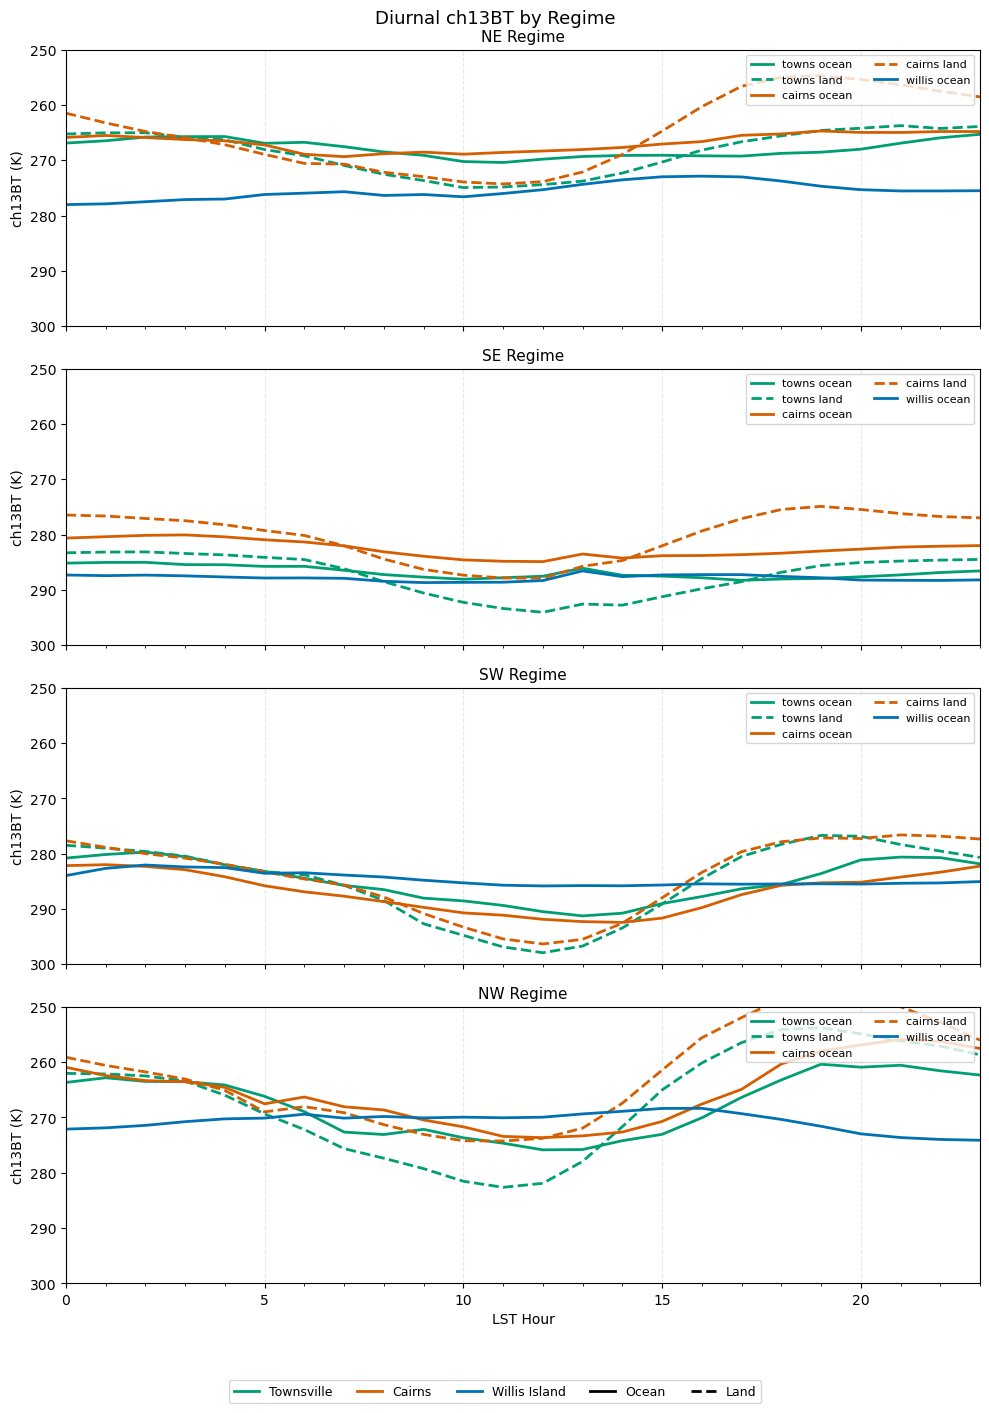

In [13]:
fig, axes = plt.subplots(4, 1, figsize=(10, 14), sharex=True, sharey=True)

# Colorblind-friendly site colours (Okabe-Ito palette)
site_colors = {
    'towns':  '#009E73',  # bluish-green
    'cairns': '#D55E00',  # vermillion/brown
    'willis': '#0072B2',  # blue
}

site_configs = {
    'towns':  {'lon': 146.5509},
    'cairns': {'lon': 145.7781},
    'willis': {'lon': 149.9641},
}

regime_labels = {'ne': 'NE', 'se': 'SE', 'sw': 'SW', 'nw': 'NW'}

for row, regime in enumerate(regimes):
    ax = axes[row]

    for site_name, cfg in site_configs.items():
        lon = cfg['lon']
        col = site_colors[site_name]
        r   = results[site_name][regime]

        # ── Ocean (solid) ──────────────────────────────────────────────────
        if r['sat_ocean'] is not None:
            lst_ocean = utc_hour_to_lst(r['sat_ocean'], lon).compute()
            ax.plot(lst_ocean, label=f'{site_name} ocean',
                    linestyle='-', lw=2, color=col)

        # ── Land (dashed) ─────────────────────────────────────────────────
        if r['sat_land'] is not None:
            lst_land = utc_hour_to_lst(r['sat_land'], lon).compute()
            ax.plot(lst_land, label=f'{site_name} land',
                    linestyle='--', lw=2, color=col)

    ax.set_title(f'{regime_labels[regime]} Regime', fontsize=11)
    ax.invert_yaxis()
    ax.set_ylim(300, 250)
    ax.set_ylabel('ch13BT (K)')
    ax.set_xlim(0, 23)
    ax.xaxis.set_minor_locator(plt.MultipleLocator(1))
    ax.grid(axis='x', which='major', ls='--', alpha=0.3)
    ax.legend(loc='upper right', fontsize=8, ncol=2)

axes[-1].set_xlabel('LST Hour')

# ── Shared legend (site + linestyle explanation) ───────────────────────────
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=site_colors['towns'],  lw=2, label='Townsville'),
    Line2D([0], [0], color=site_colors['cairns'], lw=2, label='Cairns'),
    Line2D([0], [0], color=site_colors['willis'], lw=2, label='Willis Island'),
    Line2D([0], [0], color='k', lw=2, ls='-',  label='Ocean'),
    Line2D([0], [0], color='k', lw=2, ls='--', label='Land'),
]
fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=5,
    fontsize=9,
    frameon=True,
    bbox_to_anchor=(0.5, -0.02),
)

fig.suptitle('Diurnal ch13BT by Regime', fontsize=13)
plt.tight_layout()
plt.subplots_adjust(bottom=0.07)
plt.show()

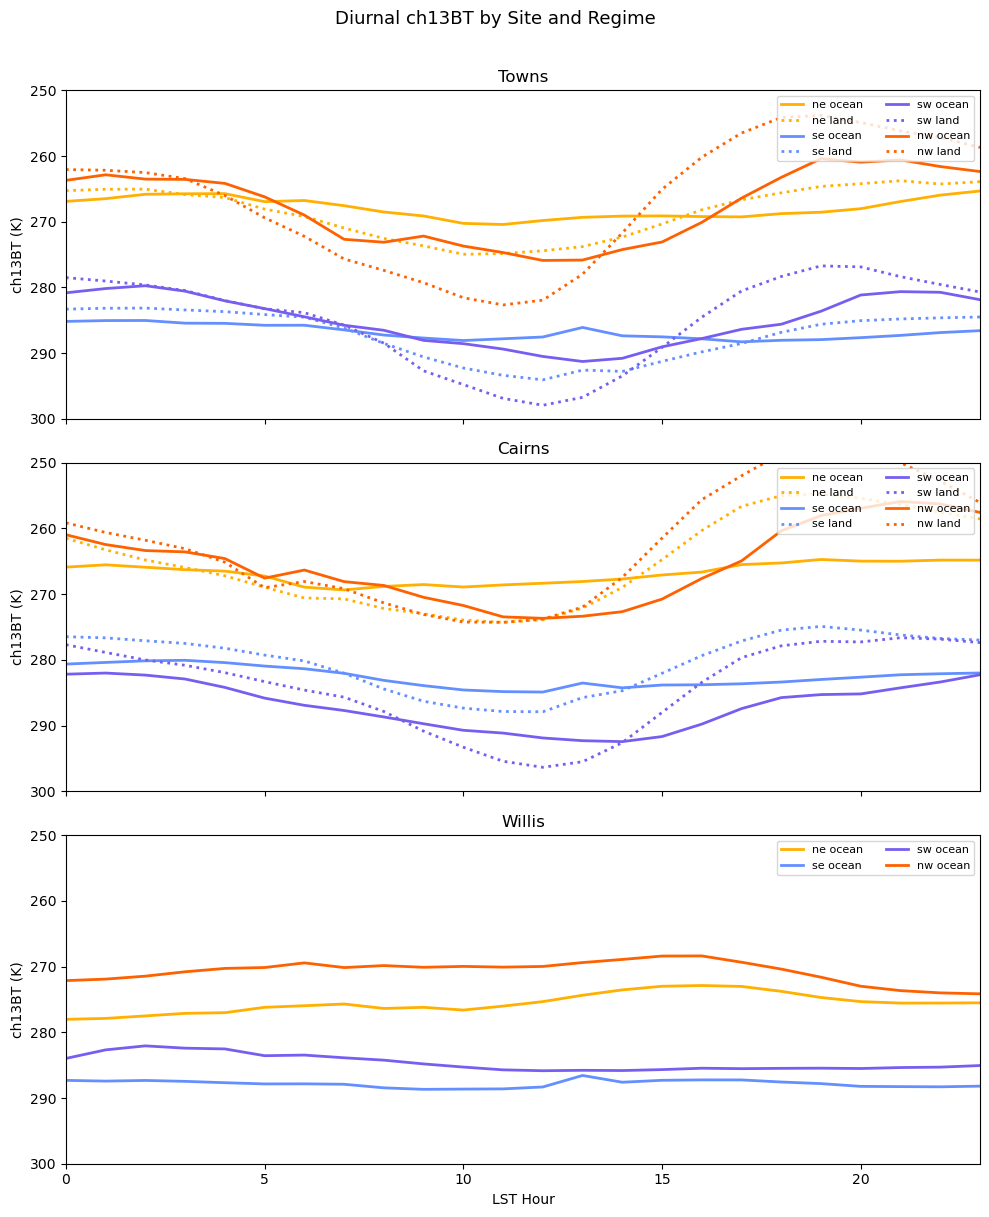

In [75]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

colors = {'ne': '#FFB000', 'se': '#648FFF', 'sw': '#785EF0', 'nw': '#FE6100'}

site_configs = {
    'towns':  {'lon': 146.5509, 'ax': axes[0]},
    'cairns': {'lon': 145.7781, 'ax': axes[1]},
    'willis': {'lon': 149.9641, 'ax': axes[2]},
}

for site_name, cfg in site_configs.items():
    ax  = cfg['ax']
    lon = cfg['lon']

    for regime in regimes:
        r   = results[site_name][regime]
        col = colors[regime]

        # ── Ocean (solid) ──────────────────────────────────────────────────
        if r['sat_ocean'] is not None:
            lst_ocean = utc_hour_to_lst(r['sat_ocean'], lon).compute()
            ax.plot(lst_ocean, label=f'{regime} ocean', linestyle='-',
                    lw=2, color=col)

        # ── Land (dotted) — towns and cairns only ──────────────────────────
        if r['sat_land'] is not None:
            lst_land = utc_hour_to_lst(r['sat_land'], lon).compute()
            ax.plot(lst_land, label=f'{regime} land', linestyle=':',
                    lw=2, color=col)

    ax.set_title(site_name.capitalize())
    ax.invert_yaxis()
    ax.set_ylim(300, 250)
    ax.set_ylabel('ch13BT (K)')
    ax.legend(loc='upper right', fontsize=8, ncol=2)
    ax.set_xlim(0, 23)

axes[-1].set_xlabel('LST Hour')
fig.suptitle('Diurnal ch13BT by Site and Regime', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Old code

In [ ]:
# def netcdf_him8(file_path,barra_site,wdir1,wdir2,ne=None):
#     with xr.open_mfdataset(file_path,engine="h5netcdf", chunks="auto") as ds:
#         ds_barra = barra_site.sortby('time') 
#         ds_selected = ds_barra.sel(time=slice('2016-01-01', '2020-04-01'))
#         barra = ds_selected.sel(time=~(ds_selected['time.month'] == 4))
#         winds = barra.wind_dir.compute()
#         if ne==True:
#             wind_dir = winds[(winds>=wdir1)&(winds<=wdir2)]
#         else:
#             wind_dir = winds[(winds>wdir1)&(winds<=wdir2)]
#         wind_dir.drop_duplicates(dim="time")
#         wind_times = wind_dir.time.values
#         towns=ds.ch13BT.sel(time=wind_times,method="nearest").sel(lat=slice(-20.768799,-18.065369),lon=slice(145.10834,147.99347))
#         cairns=ds.ch13BT.sel(time=wind_times,method="nearest").sel(lat=slice(-18.165955,-15.463379),lon=slice(144.26343,147.1026))
#         willis = ds.ch13BT.sel(time=wind_times,method="nearest").sel(lat=slice(-17.636353,-14.93396),lon=slice(148.54926,151.37994))
#     return willis 

In [ ]:
# def netcdf_him8(file_path,barra_site,wdir1,wdir2,ne=None):
#     with xr.open_mfdataset(file_path,engine="h5netcdf", chunks="auto") as ds:
#         ds_barra = barra_site.sortby('time') 
#         ds_selected = ds_barra.sel(time=slice('2016-01-01', '2020-04-01'))
#         barra = ds_selected.sel(time=~(ds_selected['time.month'] == 4))
#         winds = barra.wind_dir.compute()
#         if ne==True:
#             wind_dir = winds[(winds>=wdir1)&(winds<=wdir2)]
#         else:
#             wind_dir = winds[(winds>wdir1)&(winds<=wdir2)]
#         wind_dir.drop_duplicates(dim="time")
#         wind_times = wind_dir.time.values
#         towns=ds.ch13BT.sel(time=wind_times,method="nearest").sel(lat=slice(-20.768799,-18.065369),lon=slice(145.10834,147.99347))
#         cairns=ds.ch13BT.sel(time=wind_times,method="nearest").sel(lat=slice(-18.165955,-15.463379),lon=slice(144.26343,147.1026))
#         willis = ds.ch13BT.sel(time=wind_times,method="nearest").sel(lat=slice(-17.636353,-14.93396),lon=slice(148.54926,151.37994))
#     return willis 

In [ ]:
# barra_towns = xr.open_dataset("/home/563/ac9768/barra-2/barra-2_850hPa_winds_townsville.nc", engine="h5netcdf",chunks="auto")
# barra_cairns = xr.open_dataset("/home/563/ac9768/barra-2/barra-2_850hPa_winds_cairns.nc", engine="h5netcdf",chunks="auto")
# barra_willis = xr.open_dataset("/home/563/ac9768/barra-2/barra-2_850hPa_winds_willis_island.nc", engine="h5netcdf",chunks="auto")
# df = netcdf_him8(files,barra_willis,270,360,ne=False)
# # np.sum(np.isnan(df_land.isel(time=0).values))


In [ ]:
# df.drop_duplicates(dim="time")

<xarray.DataArray 'ch13BT' (time: 1548, lat: 150, lon: 157)> Size: 146MB
dask.array<getitem, shape=(1548, 150, 157), dtype=float32, chunksize=(149, 150, 157), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 12kB 2016-01-01T12:00:00 ... 2020-03-12T22...
  * lat      (lat) float64 1kB -17.63 -17.61 -17.59 ... -14.98 -14.96 -14.94
  * lon      (lon) float64 1kB 148.6 148.6 148.6 148.6 ... 151.3 151.4 151.4
Attributes:
    regrid_method:  bilinear

In [ ]:
# read in barra files for wind regimes
barra_towns = xr.open_dataset("/home/563/ac9768/barra-2/barra-2_850hPa_winds_townsville.nc", engine="h5netcdf",chunks="auto")
barra_cairns = xr.open_dataset("/home/563/ac9768/barra-2/barra-2_850hPa_winds_cairns.nc", engine="h5netcdf",chunks="auto")
barra_willis = xr.open_dataset("/home/563/ac9768/barra-2/barra-2_850hPa_winds_willis_island.nc", engine="h5netcdf",chunks="auto")
def read_netcdf_him8(file_path,barra_site,wdir1,wdir2,ne=None,towns=None,cairns=None):
    with xr.open_mfdataset(file_path,engine="h5netcdf", chunks="auto") as ds:
        # barra conditions
        ds_barra = barra_site.sortby('time') 
        ds_selected = ds_barra.sel(time=slice('2016-01-01', '2020-04-01'))
        barra = ds_selected.sel(time=~(ds_selected['time.month'] == 4))
        winds = barra.wind_dir.compute()
        if ne==True:
            wind_dir = winds[(winds>=wdir1)&(winds<=wdir2)]
        else:
            wind_dir = winds[(winds>wdir1)&(winds<=wdir2)]
        wind_times = wind_dir.time.values

        if towns==True:
            data_towns = ds.ch13BT.sel(time=wind_times,method="nearest").sel(lat=slice(-20.768799,-18.065369),lon=slice(145.10834,147.99347))
            bathymetry_towns = ds_bath["z"].sel(x=data_towns.lon,y=data_towns.lat,method="nearest")
            bathymetry_towns_land = bathymetry_towns> 0 
            bathymetry_towns_ocean = bathymetry_towns<= 0 
            land_towns = xr.where(bathymetry_towns_ocean, np.nan, data_towns)
            ocean_towns = xr.where(bathymetry_towns_land, np.nan, data_towns)
            mean_land = land_towns.groupby(land_towns.time.dt.hour).mean(dim=["lat","lon","time"])  
            mean_ocean = ocean_towns.groupby(ocean_towns.time.dt.hour).mean(dim=["lat","lon","time"])  
        elif cairns==True:
            data_cairns = ds.ch13BT.sel(time=wind_times,method="nearest").sel(lat=slice(-18.165955,-15.463379),lon=slice(144.26343,147.1026))
            bathymetry_cairns = ds_bath["z"].sel(x=data_cairns.lon,y=data_cairns.lat,method="nearest")
            bathymetry_cairns_land = bathymetry_cairns> 0 
            bathymetry_cairns_ocean = bathymetry_cairns<= 0 
            land_cairns = xr.where(bathymetry_cairns_ocean, np.nan, data_cairns)
            ocean_cairns = xr.where(bathymetry_cairns_land, np.nan, data_cairns)
            mean_land = land_cairns.groupby(land_cairns.time.dt.hour).mean(dim=["lat","lon","time"])  
            mean_ocean = ocean_cairns.groupby(ocean_cairns.time.dt.hour).mean(dim=["lat","lon","time"])  
        else:
            data_willis = ds.ch13BT.sel(time=wind_times,method="nearest").sel(lat=slice(-17.636353,-14.93396),lon=slice(148.54926,151.37994))
            mean_land = 1
            mean_ocean = data_willis.groupby(data_willis.time.dt.hour).mean(dim=["lat","lon","time"])  
    return mean_land,mean_ocean

In [ ]:
mean_land,mean_ocean = read_netcdf_him8(files,barra_towns,0,90,ne=True,towns=True,cairns=False)

In [ ]:
mean_landC,mean_oceanC = read_netcdf_him8(files,barra_cairns,0,90,ne=True,towns=False,cairns=True)

In [ ]:
na,mean_W = read_netcdf_him8(files,barra_willis,0,90,ne=True,towns=False,cairns=False)

In [ ]:
h8_oceanT = mean_ocean.compute()
h8_oceanC = mean_oceanC.compute()

In [ ]:
# change to aest
h8T = np.roll(h8_oceanT,shift=10)
h8C = np.roll(h8_oceanC,shift=10)

In [ ]:
# save arrays
np.save('/home/563/ac9768/himawari_regridded_files/h8_ne_cairns_ocean-v2.npy', h8C)
np.save('/home/563/ac9768/himawari_regridded_files/h8_ne_towns_ocean-v2.npy', h8T)

# Open radar dataset

In [15]:
def path_to_radar_ds(radar_site_no):
    """
    List of yyyymm (year+month) with available radar data.
    For each yyyymm create a list of entire file paths to netCDF4 files.

    Parameters:
    - radar_site_no (str): Radar site number- BoM ID's for radar locations: Townsville=73, Cairns=19, and Willis Island=41 

    Returns:
    - list: list object of netCDF4 files
    """
    list = ["202201","202202","202203","202204","202101","202102","202103","202104","202001","202002","202003","202004","201901","201902","201903","201904",
           "201801","201802","201803","201804","201701","201702","201703","201704","201601","201602","201603","201604","201501","201502",
           "201503","201504","201401","201402","201403","201404","201301","201302","201303","201304","201201","201202","201203","201204",
          ] 
    # list = ["202001","202002","202003","201901","201902","201903","201801","201802","201803","201701","201702","201703","201601","201602","201603","201501","201502","201503",
    #       ] 
    files_list = []
    for i in list:
        fp = "/g/data/rq0/admin/level_2_decomissioned_fields/"+radar_site_no+"/RAINRATE/"
        all_files = [os.path.join(root, f) for root, _, files in os.walk(fp)
            for f in files
            if f.startswith(radar_site_no+'_'+i) and f.endswith('.nc')]
        files_list.extend(all_files)
    files_list.sort()
    return files_list

# towns_radar_files = path_to_radar_ds("73")
# cairns_radar_files = path_to_radar_ds("19")
willis_radar_files = path_to_radar_ds("41")

In [4]:
def create_radar_mask(file_path, threshold,chunks={'time': 'auto', 'x': 'auto', 'y': 'auto'},land=None,ocean=None):
    ds_full = xr.open_dataset('/home/563/ac9768/GBR/Aus_Bathymetry/ETOPO2v2c_f4.GQp62nWv.nc.part',engine="netcdf4")
    ds_bath = ds_full.sel(x=slice(140,155),y=slice(-22,-11))
    print("bathymetry")
    with xr.open_mfdataset(file_path, engine="netcdf4",combine='by_coords', chunks=chunks, parallel=True) as ds:
        ds_mean = ds.rainrate.mean(dim='time')
        condition1 = ~ds.rainrate.mean(dim='time').isnull()
        print(condition1.compute().sum())
        print("calculated mean rr")
        file = xr.open_dataset(file_path[0], engine="netcdf4") 
        bathymetry = ds_bath["z"].sel(x=file.longitude,y=file.latitude,method="nearest")
        masked_beam_blockage = xr.where((ds_mean < threshold), np.zeros_like(ds_mean),np.ones_like(ds_mean)) ##each hour then has its own mask
        if land==True:
            bath = xr.where((bathymetry <= 0), np.zeros_like(bathymetry),np.ones_like(bathymetry))
            condition2 = bath.astype(bool)
            condition3 = masked_beam_blockage.astype(bool)
            mask = condition1 & condition2 & condition3
        elif ocean==True:
            bath = xr.where((bathymetry > 0), np.zeros_like(bathymetry),np.ones_like(bathymetry))
            condition2 = bath.astype(bool)
            condition3 = masked_beam_blockage.astype(bool)
            mask = condition1 & condition2 & condition3
        else:
            mask = ~ds.rainrate.mean(dim='time').isnull()
    return mask 

In [1]:
def process_hour_freq(ds):
    """
    Sum the number of non raining points (value = 0) across x, y and time ignoring Nans. Sum the
    number of raining points. Compute those values. Calculate the total of valid data points (raining + non-raining). Calculate the frequency
    where the number of raining points is divided by the total valid points * 100.
    
    Parameters:
    - ds (str): Path to the netCDF file(s).
    
    Returns:
    - int: Frequency of raining points (%)
    """
    number_of_nonraining_points = (ds == 0).where(~ds.isnull()).sum(dim=['x', 'y', 'time'])
    number_of_raining_points = (ds != 0).where(~ds.isnull()).sum(dim=['x', 'y', 'time'])
    total_count = (number_of_nonraining_points) + (number_of_raining_points)
    freq = (number_of_raining_points / total_count) * 100
    return freq

# Plot new radar/BT data

In [12]:
def utc_hour_to_lst(da, longitude_center: float):
    offset_hours = round(longitude_center * 4 / 60)
    # print(offset_hours)
    da_lst = da.roll(hour=offset_hours)  # negative to shift forward in LST
    da_lst = da_lst.assign_coords(hour=(da_lst.hour % 24))
    da_lst = da_lst.sortby('hour')
    return da_lst

lon_centers = {
    'cairns': (144.27374 + 147.09222) / 2,
    'willis': (148.55927 + 151.36993) / 2,
}

In [17]:
regimes = ['nw', 'ne', 'sw', 'se']
colors  = {'nw': '#FE6100', 'ne': '#FFB000', 'sw': '#785EF0', 'se': '#648FFF'}
base    = '/home/563/ac9768/GBR/scripts/Paper_figures/Fig6_12LST_windregime_def'

Tocean, Tland, Tocean_freq, Tland_freq = {}, {}, {}, {}
ocean, land, ocean_freq, land_freq = {}, {}, {}, {}
willis_ocean, willis_ocean_freq = {}, {}

for regime in regimes:
    Tocean[regime]      = xr.open_zarr(f'{base}/towns_{regime}_ocean_mean_rainrate.zarr').rainrate
    Tland[regime]       = xr.open_zarr(f'{base}/towns_{regime}_land_mean_rainrate.zarr').rainrate
    Tocean_freq[regime] = xr.open_zarr(f'{base}/towns_{regime}_ocean_freq.zarr').freq
    Tland_freq[regime]  = xr.open_zarr(f'{base}/towns_{regime}_land_freq.zarr').freq
    ocean[regime]      = xr.open_zarr(f'{base}/cairns_{regime}_ocean_mean_rainrate.zarr').rainrate
    land[regime]       = xr.open_zarr(f'{base}/cairns_{regime}_land_mean_rainrate.zarr').rainrate
    ocean_freq[regime] = xr.open_zarr(f'{base}/cairns_{regime}_ocean_freq.zarr').freq
    land_freq[regime]  = xr.open_zarr(f'{base}/cairns_{regime}_land_freq.zarr').freq
    willis_ocean[regime]      = xr.open_zarr(f'{base}/willis_{regime}_ocean_mean_rainrate.zarr').rainrate
    willis_ocean_freq[regime] = xr.open_zarr(f'{base}/willis_{regime}_ocean_freq.zarr').freq
bt = {
    'towns_land': {},
    'towns_ocean': {},
    'cairns_land':   {},
    'cairns_ocean':  {},
    'willis_ocean':  {},
}
bt_dir = '/home/563/ac9768/GBR/scripts/Paper_figures/Fig6_12LST_windregime_def'

for regime in regimes:
    bt['towns_land'][regime]  = xr.open_dataset(f'{bt_dir}/him8_diurnal_towns_{regime}_land.nc').ch13BT
    bt['towns_ocean'][regime] = xr.open_dataset(f'{bt_dir}/him8_diurnal_towns_{regime}_ocean.nc').ch13BT
    bt['cairns_land'][regime]  = xr.open_dataset(f'{bt_dir}/him8_diurnal_cairns_{regime}_land.nc').ch13BT
    bt['cairns_ocean'][regime] = xr.open_dataset(f'{bt_dir}/him8_diurnal_cairns_{regime}_ocean.nc').ch13BT
    bt['willis_ocean'][regime] = xr.open_dataset(f'{bt_dir}/him8_diurnal_willis_{regime}_ocean.nc').ch13BT


In [26]:
lon_centers = {
    'towns': 146.5509,
    'cairns':  145.683,
    'willis': 149.9646,
}
utc_hour_to_lst(land_freq['nw'],lon_centers['cairns']).values
# bt['cairns_land']['nw'].values

array([24.46548244, 22.32266744, 20.03707396, 18.02270599, 15.96565721,
       12.7743384 ,  9.57834513,  7.90864383,  7.73853606,  8.03759248,
        8.99788084, 11.56276791, 13.87337512, 17.00236598, 20.33473397,
       22.70173413, 24.86660993, 26.87401901, 28.01738411, 33.36545479,
       35.32335182, 33.10617949, 30.93578105, 27.77558323])

In [11]:
(land['ne'].max().values-land['ne'].min().values)/2

np.float64(0.6128759240350071)

made dict, starting plotting...
regimes...


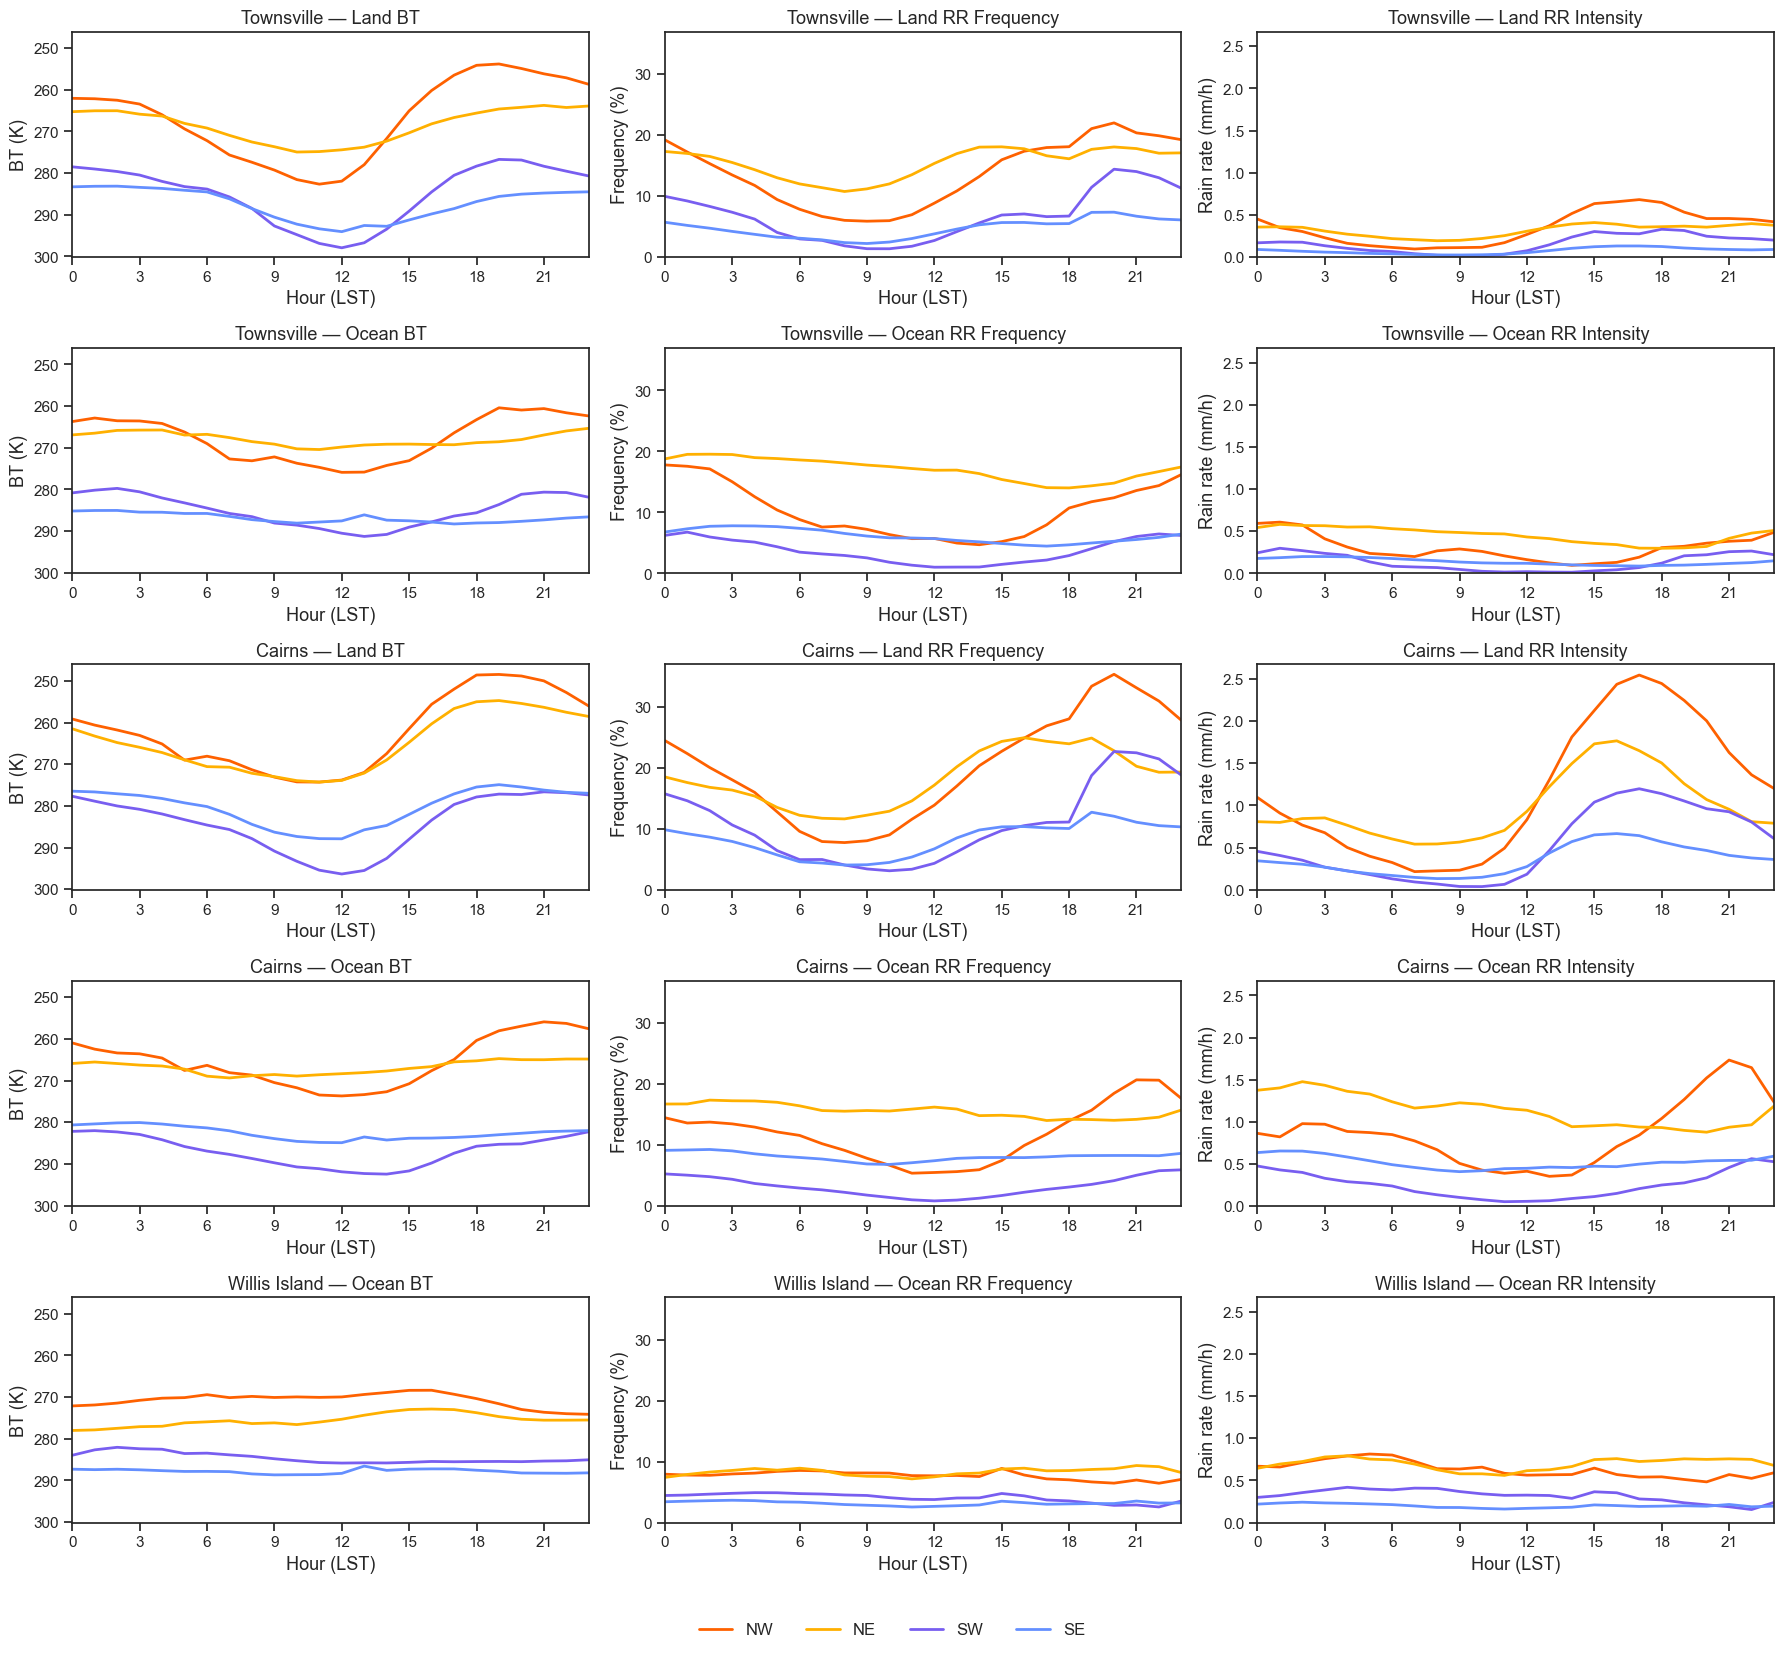

In [9]:
regimes = ['nw', 'ne', 'sw', 'se']
colors  = {'nw': '#FE6100', 'ne': '#FFB000', 'sw': '#785EF0', 'se': '#648FFF'}
base    = '/home/563/ac9768/GBR/scripts/Paper_figures/Fig6_12LST_windregime_def'

Tocean, Tland, Tocean_freq, Tland_freq = {}, {}, {}, {}
ocean, land, ocean_freq, land_freq = {}, {}, {}, {}
willis_ocean, willis_ocean_freq = {}, {}

for regime in regimes:
    Tocean[regime]      = xr.open_zarr(f'{base}/towns_{regime}_ocean_mean_rainrate.zarr').rainrate
    Tland[regime]       = xr.open_zarr(f'{base}/towns_{regime}_land_mean_rainrate.zarr').rainrate
    Tocean_freq[regime] = xr.open_zarr(f'{base}/towns_{regime}_ocean_freq.zarr').freq
    Tland_freq[regime]  = xr.open_zarr(f'{base}/towns_{regime}_land_freq.zarr').freq
    ocean[regime]      = xr.open_zarr(f'{base}/cairns_{regime}_ocean_mean_rainrate.zarr').rainrate
    land[regime]       = xr.open_zarr(f'{base}/cairns_{regime}_land_mean_rainrate.zarr').rainrate
    ocean_freq[regime] = xr.open_zarr(f'{base}/cairns_{regime}_ocean_freq.zarr').freq
    land_freq[regime]  = xr.open_zarr(f'{base}/cairns_{regime}_land_freq.zarr').freq
    willis_ocean[regime]      = xr.open_zarr(f'{base}/willis_{regime}_ocean_mean_rainrate.zarr').rainrate
    willis_ocean_freq[regime] = xr.open_zarr(f'{base}/willis_{regime}_ocean_freq.zarr').freq

print('made dict, starting plotting...')
fig, axes = plt.subplots(5, 3, figsize=(18, 16))
sns.set_theme(style="ticks")

lon_centers = {
    'towns': 146.5509,
    'cairns':  145.683,
    'willis': 149.9646,
}
lon_t = lon_centers['towns']
lon_c = lon_centers['cairns']
lon_w = lon_centers['willis']
hours = np.arange(0, 24, 1)

# ── Load BT data ──────────────────────────────────────────────────────────────
# Assumes saved nc files from previous step
bt_dir = '/home/563/ac9768/GBR/scripts/Paper_figures/Fig6_12LST_windregime_def'

bt = {
    'towns_land': {},
    'towns_ocean': {},
    'cairns_land':   {},
    'cairns_ocean':  {},
    'willis_ocean':  {},
}
for regime in regimes:
    bt['towns_land'][regime]  = xr.open_dataset(f'{bt_dir}/him8_diurnal_towns_{regime}_land.nc').ch13BT
    bt['towns_ocean'][regime] = xr.open_dataset(f'{bt_dir}/him8_diurnal_towns_{regime}_ocean.nc').ch13BT
    bt['cairns_land'][regime]  = xr.open_dataset(f'{bt_dir}/him8_diurnal_cairns_{regime}_land.nc').ch13BT
    bt['cairns_ocean'][regime] = xr.open_dataset(f'{bt_dir}/him8_diurnal_cairns_{regime}_ocean.nc').ch13BT
    bt['willis_ocean'][regime] = xr.open_dataset(f'{bt_dir}/him8_diurnal_willis_{regime}_ocean.nc').ch13BT

print('regimes...')
for regime, color in colors.items():
    # ── Townsville ────────────────────────────────────────────────────────────
    freq_tl  = utc_hour_to_lst(Tland_freq[regime],  lon_t).values
    mean_tl  = utc_hour_to_lst(Tland[regime],        lon_t).values
    freq_to  = utc_hour_to_lst(Tocean_freq[regime],  lon_t).values
    mean_to  = utc_hour_to_lst(Tocean[regime],       lon_t).values
    bt_tl   = bt['towns_land'][regime].values
    bt_to   = bt['towns_ocean'][regime].values
    
    # ── Cairns ────────────────────────────────────────────────────────────────
    freq_l  = utc_hour_to_lst(land_freq[regime],  lon_c).values
    mean_l  = utc_hour_to_lst(land[regime],        lon_c).values
    freq_o  = utc_hour_to_lst(ocean_freq[regime],  lon_c).values
    mean_o  = utc_hour_to_lst(ocean[regime],       lon_c).values
    bt_cl   = bt['cairns_land'][regime].values
    bt_co   = bt['cairns_ocean'][regime].values

    # ── Willis ────────────────────────────────────────────────────────────────
    freq_wo = utc_hour_to_lst(willis_ocean_freq[regime], lon_w).values
    mean_wo = utc_hour_to_lst(willis_ocean[regime],      lon_w).values
    bt_wo   = bt['willis_ocean'][regime].values

    # col 0: BT  |  col 1: Frequency  |  col 2: Rain rate
    axes[0, 0].plot(hours, bt_tl,   color=color, lw=2, label=regime.upper())
    axes[0, 1].plot(hours, freq_tl,  color=color, lw=2, label=regime.upper())
    axes[0, 2].plot(hours, mean_tl,  color=color, lw=2, label=regime.upper())

    axes[1, 0].plot(hours, bt_to,   color=color, lw=2, label=regime.upper())
    axes[1, 1].plot(hours, freq_to,  color=color, lw=2, label=regime.upper())
    axes[1, 2].plot(hours, mean_to,  color=color, lw=2, label=regime.upper())
    
    axes[2, 0].plot(hours, bt_cl,   color=color, lw=2, label=regime.upper())
    axes[2, 1].plot(hours, freq_l,  color=color, lw=2, label=regime.upper())
    axes[2, 2].plot(hours, mean_l,  color=color, lw=2, label=regime.upper())

    axes[3, 0].plot(hours, bt_co,   color=color, lw=2, label=regime.upper())
    axes[3, 1].plot(hours, freq_o,  color=color, lw=2, label=regime.upper())
    axes[3, 2].plot(hours, mean_o,  color=color, lw=2, label=regime.upper())

    axes[4, 0].plot(hours, bt_wo,   color=color, lw=2, label=regime.upper())
    axes[4, 1].plot(hours, freq_wo, color=color, lw=2, label=regime.upper())
    axes[4, 2].plot(hours, mean_wo, color=color, lw=2, label=regime.upper())

# ── Panel titles ──────────────────────────────────────────────────────────────
panel_titles = [
    ['Townsville — Land BT',              'Townsville — Land RR Frequency',         'Townsville — Land RR Intensity'],
    ['Townsville — Ocean BT',             'Townsville — Ocean RR Frequency',        'Townsville — Ocean RR Intensity'],
    ['Cairns — Land BT',              'Cairns — Land RR Frequency',         'Cairns — Land RR Intensity'],
    ['Cairns — Ocean BT',             'Cairns — Ocean RR Frequency',        'Cairns — Ocean RR Intensity'],
    ['Willis Island — Ocean BT',      'Willis Island — Ocean RR Frequency', 'Willis Island — Ocean RR Intensity'],
]
ylabels_col = ['BT (K)', 'Frequency (%)', 'Rain rate (mm/h)']

for row in range(5):
    for col in range(3):
        axes[row, col].set_xlim(0, 23)
        axes[row, col].set_xticks(np.arange(0, 24, 3))
        axes[row, col].set_xlabel('Hour (LST)', fontsize=13)
        axes[row, col].set_title(panel_titles[row][col], fontsize=13)
        axes[row, col].tick_params(labelsize=11)
        axes[row, col].set_ylabel(ylabels_col[col], fontsize=13)

# ── Shared y-limits within each column ───────────────────────────────────────
for col, panels in enumerate([
    [axes[r, 0] for r in range(5)],   # BT col
    [axes[r, 1] for r in range(5)],   # freq col
    [axes[r, 2] for r in range(5)],   # RR col
]):
    if col == 0:
        # BT: invert y-axis, share limits
        ymin = min(ax.get_ylim()[0] for ax in panels)
        ymax = max(ax.get_ylim()[1] for ax in panels)
        for ax in panels:
            ax.set_ylim(ymax, ymin)   # inverted
    else:
        ymax = max(ax.get_ylim()[1] for ax in panels)
        for ax in panels:
            ax.set_ylim(0, ymax)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.01),
           ncol=4, frameon=False, fontsize=12)
plt.tight_layout()
plt.show()

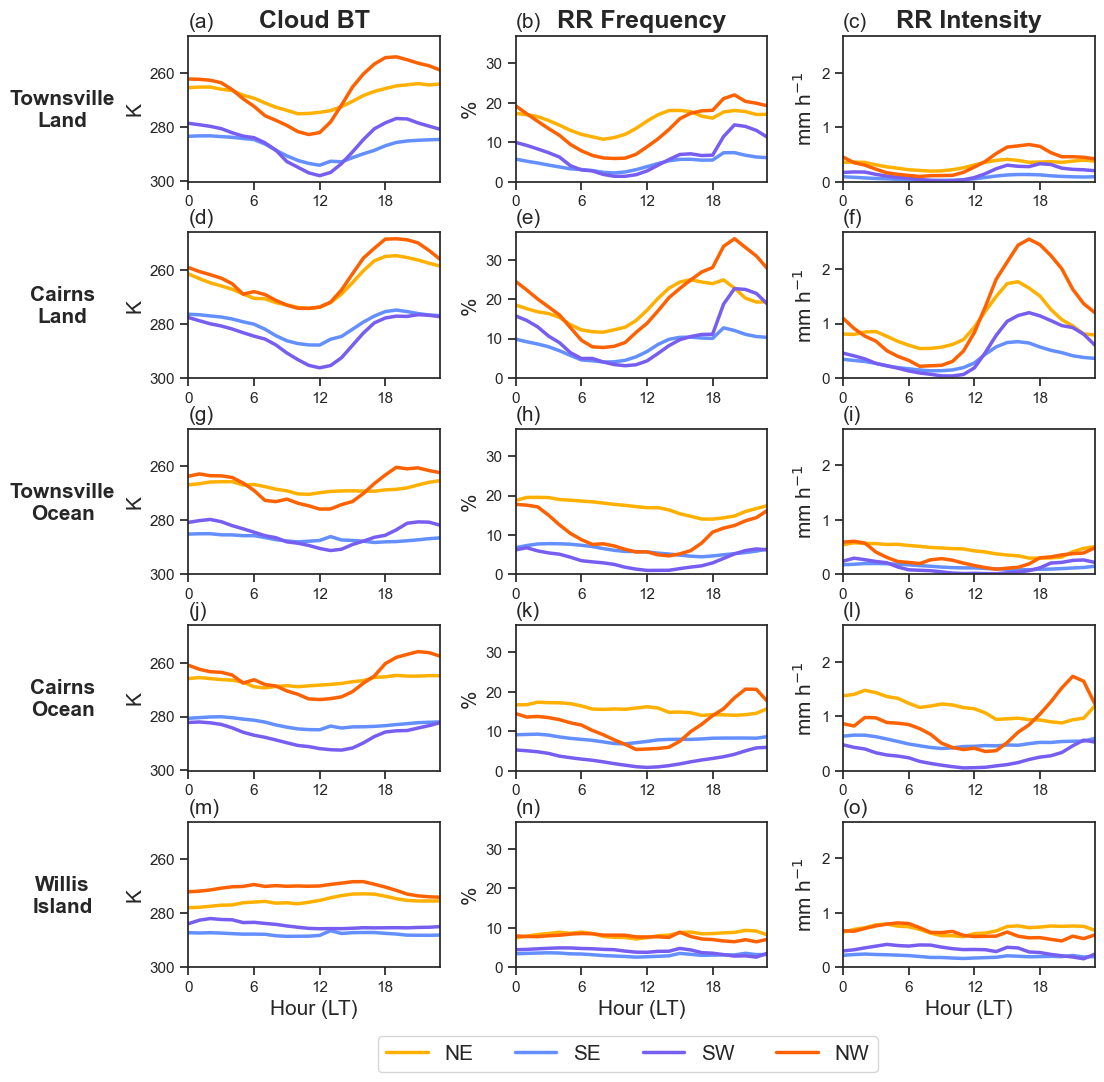

In [17]:
# plot same format as used in manuscript
fig, axes = plt.subplots(5, 3, figsize=(10, 10))
fig.tight_layout()
sns.set_theme(style="ticks")

lon_t = lon_centers['towns']
lon_c = lon_centers['cairns']
lon_w = lon_centers['willis']
hours = np.arange(0, 24, 1)

titles   = ['Cloud BT', 'RR Frequency', 'RR Intensity']
ylabels  = ['Townsville\nLand', 'Cairns\nLand', 'Townsville\nOcean', 'Cairns\nOcean', 'Willis\nIsland']
regime_labels = ['NE','SE', 'SW', 'NW']
regimes = ['ne','se', 'sw', 'nw']
colors  = {'ne': '#FFB000', 'se': '#648FFF','sw': '#785EF0','nw': '#FE6100',}
# ── Column titles (bold, large) ───────────────────────────────────────────────
for col, title in enumerate(titles):
    axes[0, col].set_title(title, fontsize=18, pad=15, weight='bold')

# ── Row/col formatting ────────────────────────────────────────────────────────
for row in range(5):
    for col in range(3):
        letter = chr(97 + row * 3 + col)
        axes[row, col].set_title(f'({letter})', loc='left', fontsize=15)
        axes[row, col].set_xlim(0, 23)
        axes[row, col].set_xticks(np.arange(0, 24, 6))
        if row == 4:
            axes[row, col].set_xlabel('Hour (LT)', fontsize=15)
        axes[row, col].tick_params(labelsize=11)

    # y-axis limits and labels
    axes[row, 0].set_ylabel('K',            fontsize=15)
    axes[row, 1].set_ylabel('%',            fontsize=15)
    axes[row, 2].set_ylabel('mm h$^{-1}$', fontsize=15)

    # Bold site label to the left of col-0
    axes[row, 0].text(
        x=-0.5, y=0.35, s=ylabels[row],
        fontsize=15, ha='center', va='bottom',
        rotation=0, transform=axes[row, 0].transAxes,
        weight='bold',
    )

# ── Plot data ─────────────────────────────────────────────────────────────────
row_cfg = [
    # (row, bt_key,            freq_dict,    mean_dict,    lon  )
    (0,  'towns_land',   Tland_freq,        Tland,        lon_t),
    (1,  'cairns_land',  land_freq,         land,         lon_c),
    (2,  'towns_ocean',  Tocean_freq,       Tocean,       lon_t),
    (3,  'cairns_ocean', ocean_freq,        ocean,        lon_c),
    (4,  'willis_ocean', willis_ocean_freq, willis_ocean, lon_w),
]

for regime, color in colors.items():
    for row, bt_key, freq_dict, mean_dict, lon in row_cfg:
        bt_vals   = bt[bt_key][regime].values
        freq_vals = utc_hour_to_lst(freq_dict[regime], lon).values
        mean_vals = utc_hour_to_lst(mean_dict[regime], lon).values

        axes[row, 0].plot(hours, bt_vals,   color=color, lw=2.5, label=regime.upper())
        axes[row, 1].plot(hours, freq_vals, color=color, lw=2.5, label=regime.upper())
        axes[row, 2].plot(hours, mean_vals, color=color, lw=2.5, label=regime.upper())

# ── Shared y-limits per column, BT inverted ───────────────────────────────────
bt_min   = min(axes[r, 0].get_ylim()[0] for r in range(5))
bt_max   = max(axes[r, 0].get_ylim()[1] for r in range(5))
freq_max = max(axes[r, 1].get_ylim()[1] for r in range(5))
rr_max   = max(axes[r, 2].get_ylim()[1] for r in range(5))

for row in range(5):
    axes[row, 0].set_ylim(bt_max, bt_min)   # inverted
    axes[row, 1].set_ylim(0, freq_max)
    axes[row, 2].set_ylim(0, rr_max)

# ── Shared legend ─────────────────────────────────────────────────────────────
handles, _ = axes[0, 0].get_legend_handles_labels()
# One handle per regime (deduplicate)
handles = handles[:len(regimes)]
fig.legend(
    handles=handles,
    labels=regime_labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.07),
    fontsize=15,
    ncol=len(regime_labels),
    frameon=True,
)

fig.savefig(
    '/home/563/ac9768/GBR/scripts/Paper_figures/f06v4_newdata.png',
    bbox_inches='tight', dpi=300,
)
plt.show()

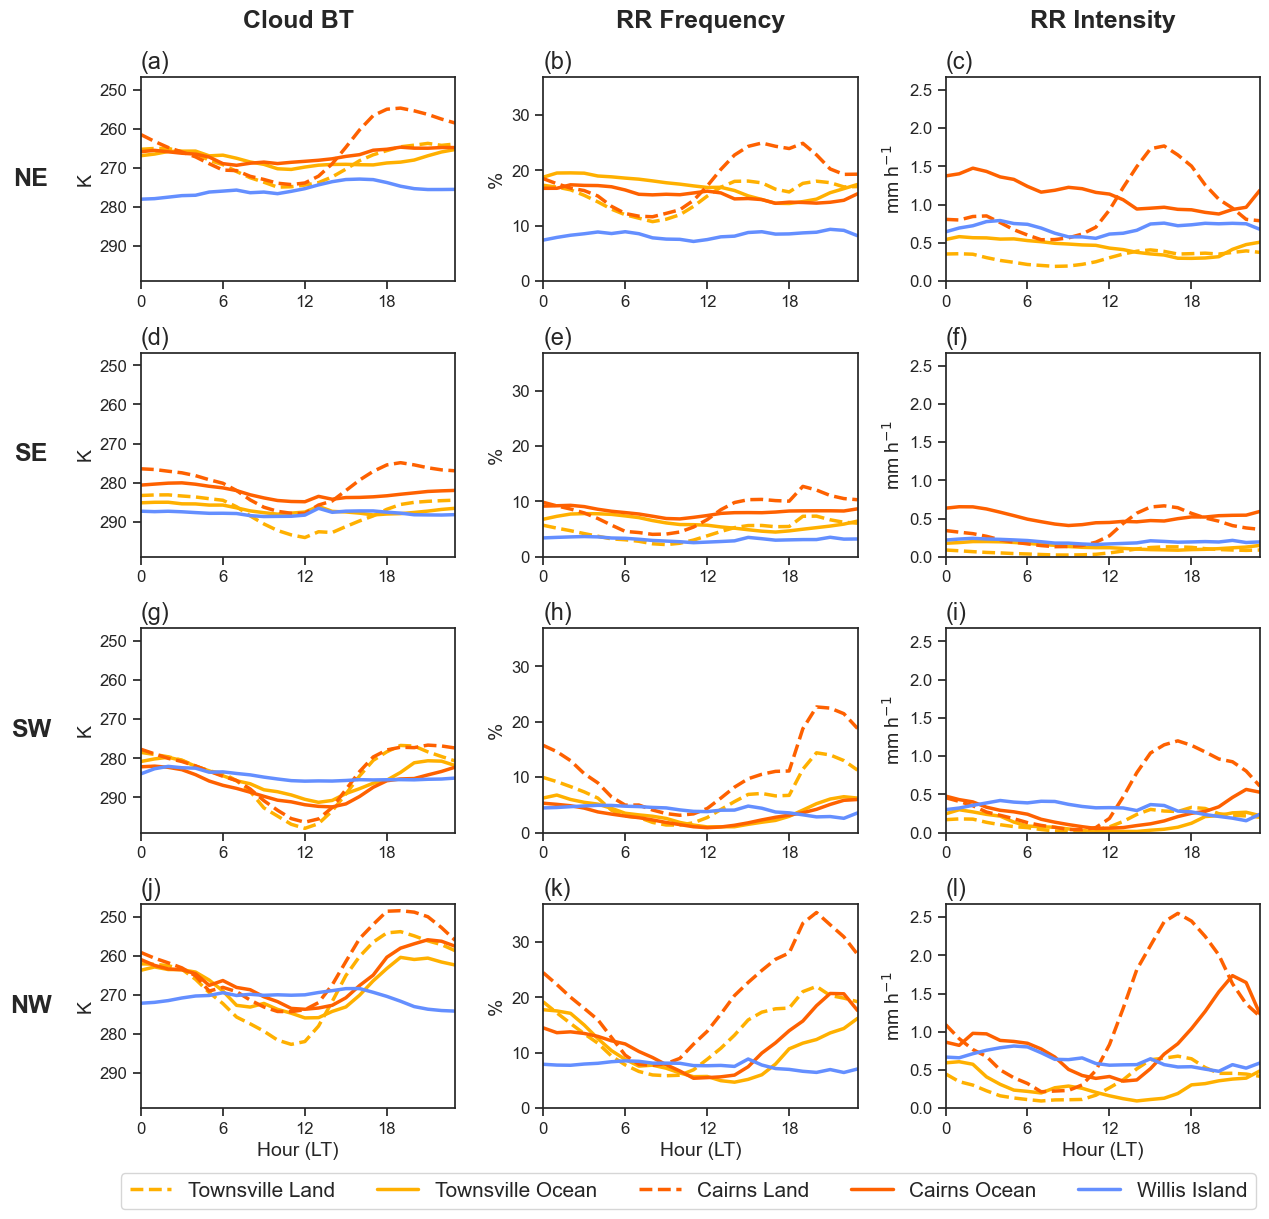

In [35]:
# plot another format
fig, axes = plt.subplots(4, 3, figsize=(12, 11))
fig.tight_layout()
sns.set_theme(style="ticks")
fig.subplots_adjust(
    hspace=0.35,  # vertical spacing between rows
    wspace=0.28   # horizontal spacing between columns
)
hours = np.arange(0, 24, 1)

titles        = ['Cloud BT', 'RR Frequency', 'RR Intensity']
regime_labels = ['NE', 'SE', 'SW', 'NW']
regimes       = ['ne', 'se', 'sw', 'nw']

# Okabe-Ito colorblind-friendly palette
colors  = {'ne': '#FFB000', 'se': '#648FFF','sw': '#785EF0','nw': '#FE6100',}
site_colors = {
    'towns':  '#FFB000',#'#FE6100',#44AA99' ,#009E73',   # bluish-green
    'cairns': '#FE6100',#'#DC267F',#DDCC77',#D55E00',   # vermillion
    'willis': '#648FFF',#'#785EF0',#88CCEE',#0072B2',   # blue
}

# (label, bt_key, freq_dict, mean_dict, lon, linestyle)
series_cfg = [
    ('Townsville Land',  'towns_land',   Tland_freq,        Tland,        lon_t, '--', 'towns'),
    ('Townsville Ocean', 'towns_ocean',  Tocean_freq,       Tocean,       lon_t, '-',  'towns'),
    ('Cairns Land',      'cairns_land',  land_freq,         land,         lon_c, '--', 'cairns'),
    ('Cairns Ocean',     'cairns_ocean', ocean_freq,        ocean,        lon_c, '-',  'cairns'),
    ('Willis Island',    'willis_ocean', willis_ocean_freq, willis_ocean, lon_w, '-',  'willis'),
]

# ── Column titles ─────────────────────────────────────────────────────────────
for col, title in enumerate(titles):
    axes[0, col].set_title(title, fontsize=18,y=1.2, pad=15, weight='bold')

# ── Formatting ────────────────────────────────────────────────────────────────
for row in range(4):
    for col in range(3):
        letter = chr(97 + row * 3 + col)
        axes[row, col].set_title(f'({letter})', loc='left', fontsize=17)
        axes[row, col].set_xlim(0, 23)
        axes[row, col].set_xticks(np.arange(0, 24, 6))
        axes[row, col].tick_params(labelsize=12)
        if row == 3:
            axes[row, col].set_xlabel('Hour (LT)', fontsize=14)

    axes[row, 0].set_ylabel('K',            fontsize=14)
    axes[row, 1].set_ylabel('%',            fontsize=14)
    axes[row, 2].set_ylabel('mm h$^{-1}$', fontsize=14)

    # Regime label to the left of col-0
    axes[row, 0].text(
        x=-0.35, y=0.5, s=regime_labels[row],
        fontsize=18, ha='center', va='center',
        rotation=0, transform=axes[row, 0].transAxes,
        weight='bold',
    )

# ── Plot ──────────────────────────────────────────────────────────────────────
for row, regime in enumerate(regimes):
    for label, bt_key, freq_dict, mean_dict, lon, ls, site in series_cfg:
        col   = site_colors[site]
        bt_v  = bt[bt_key][regime].values
        frq_v = utc_hour_to_lst(freq_dict[regime], lon).values
        rr_v  = utc_hour_to_lst(mean_dict[regime], lon).values

        kw = dict(color=col, lw=2.5, linestyle=ls,
                  label=label if row == 0 else '_nolegend_')

        axes[row, 0].plot(hours, bt_v,  **kw)
        axes[row, 1].plot(hours, frq_v, **kw)
        axes[row, 2].plot(hours, rr_v,  **kw)

# ── Shared y-limits, BT inverted ─────────────────────────────────────────────
bt_min   = min(axes[r, 0].get_ylim()[0] for r in range(4))
bt_max   = max(axes[r, 0].get_ylim()[1] for r in range(4))
freq_max = max(axes[r, 1].get_ylim()[1] for r in range(4))
rr_max   = max(axes[r, 2].get_ylim()[1] for r in range(4))

for row in range(4):
    axes[row, 0].set_ylim(bt_max, bt_min)
    axes[row, 1].set_ylim(0, freq_max)
    axes[row, 2].set_ylim(0, rr_max)

# ── Legend ────────────────────────────────────────────────────────────────────
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color=site_colors['towns'],  lw=2.5, ls='--', label='Townsville Land'),
    Line2D([0], [0], color=site_colors['towns'],  lw=2.5, ls='-',  label='Townsville Ocean'),
    Line2D([0], [0], color=site_colors['cairns'], lw=2.5, ls='--', label='Cairns Land'),
    Line2D([0], [0], color=site_colors['cairns'], lw=2.5, ls='-',  label='Cairns Ocean'),
    Line2D([0], [0], color=site_colors['willis'], lw=2.5, ls='-',  label='Willis Island'),
]

fig.legend(
    handles=legend_elements,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.06),
    fontsize=15,
    ncol=5,
    frameon=True,
)

fig.savefig(
    '/home/563/ac9768/GBR/scripts/Paper_figures/f06v8_byregime.png',
    bbox_inches='tight', dpi=300,
)
plt.show()

In [42]:
# with clim ---------------------------------
regimes = ['nw', 'ne', 'sw', 'se','clim']
colors  = {'nw': '#FE6100', 'ne': '#FFB000', 'sw': '#785EF0', 'se': '#648FFF','clim':'black'}
base    = '/home/563/ac9768/GBR/scripts/Paper_figures/Fig6_12LST_windregime_def'
base_clim    = '/home/563/ac9768/GBR/scripts/Paper_figures/Fig11_diurnal_clim'

Tocean, Tland, Tocean_freq, Tland_freq = {}, {}, {}, {}
ocean, land, ocean_freq, land_freq = {}, {}, {}, {}
willis_ocean, willis_ocean_freq = {}, {}

for regime in regimes:
    if regime=='clim':
        Tocean[regime]      = xr.open_zarr(f'{base_clim}/towns_{regime}_ocean_mean_rainrate.zarr').rainrate
        Tland[regime]       = xr.open_zarr(f'{base_clim}/towns_{regime}_land_mean_rainrate.zarr').rainrate
        Tocean_freq[regime] = xr.open_zarr(f'{base_clim}/towns_{regime}_ocean_freq.zarr').freq
        Tland_freq[regime]  = xr.open_zarr(f'{base_clim}/towns_{regime}_land_freq.zarr').freq
        ocean[regime]      = xr.open_zarr(f'{base_clim}/cairns_{regime}_ocean_mean_rainrate.zarr').rainrate
        land[regime]       = xr.open_zarr(f'{base_clim}/cairns_{regime}_land_mean_rainrate.zarr').rainrate
        ocean_freq[regime] = xr.open_zarr(f'{base_clim}/cairns_{regime}_ocean_freq.zarr').freq
        land_freq[regime]  = xr.open_zarr(f'{base_clim}/cairns_{regime}_land_freq.zarr').freq
        willis_ocean[regime]      = xr.open_zarr(f'{base_clim}/willis_{regime}_ocean_mean_rainrate.zarr').rainrate
        willis_ocean_freq[regime] = xr.open_zarr(f'{base_clim}/willis_{regime}_ocean_freq.zarr').freq
    else:
        Tocean[regime]      = xr.open_zarr(f'{base}/towns_{regime}_ocean_mean_rainrate.zarr').rainrate
        Tland[regime]       = xr.open_zarr(f'{base}/towns_{regime}_land_mean_rainrate.zarr').rainrate
        Tocean_freq[regime] = xr.open_zarr(f'{base}/towns_{regime}_ocean_freq.zarr').freq
        Tland_freq[regime]  = xr.open_zarr(f'{base}/towns_{regime}_land_freq.zarr').freq
        ocean[regime]      = xr.open_zarr(f'{base}/cairns_{regime}_ocean_mean_rainrate.zarr').rainrate
        land[regime]       = xr.open_zarr(f'{base}/cairns_{regime}_land_mean_rainrate.zarr').rainrate
        ocean_freq[regime] = xr.open_zarr(f'{base}/cairns_{regime}_ocean_freq.zarr').freq
        land_freq[regime]  = xr.open_zarr(f'{base}/cairns_{regime}_land_freq.zarr').freq
        willis_ocean[regime]      = xr.open_zarr(f'{base}/willis_{regime}_ocean_mean_rainrate.zarr').rainrate
        willis_ocean_freq[regime] = xr.open_zarr(f'{base}/willis_{regime}_ocean_freq.zarr').freq
bt = {
    'towns_land': {},
    'towns_ocean': {},
    'cairns_land':   {},
    'cairns_ocean':  {},
    'willis_ocean':  {},
}
bt_dir = '/home/563/ac9768/GBR/scripts/Paper_figures/Fig6_12LST_windregime_def/archive'

for regime in regimes:
    bt['towns_land'][regime]  = xr.open_dataset(f'{bt_dir}/him8_diurnal_towns_{regime}_land.nc').ch13BT
    bt['towns_ocean'][regime] = xr.open_dataset(f'{bt_dir}/him8_diurnal_towns_{regime}_ocean.nc').ch13BT
    bt['cairns_land'][regime]  = xr.open_dataset(f'{bt_dir}/him8_diurnal_cairns_{regime}_land.nc').ch13BT
    bt['cairns_ocean'][regime] = xr.open_dataset(f'{bt_dir}/him8_diurnal_cairns_{regime}_ocean.nc').ch13BT
    bt['willis_ocean'][regime] = xr.open_dataset(f'{bt_dir}/him8_diurnal_willis_{regime}_ocean.nc').ch13BT

lon_centers = {
    'towns': 146.5509,
    'cairns':  145.683,
    'willis': 149.9646,
}
lon_t = lon_centers['towns']
lon_c = lon_centers['cairns']
lon_w = lon_centers['willis']
hours = np.arange(0, 24, 1)

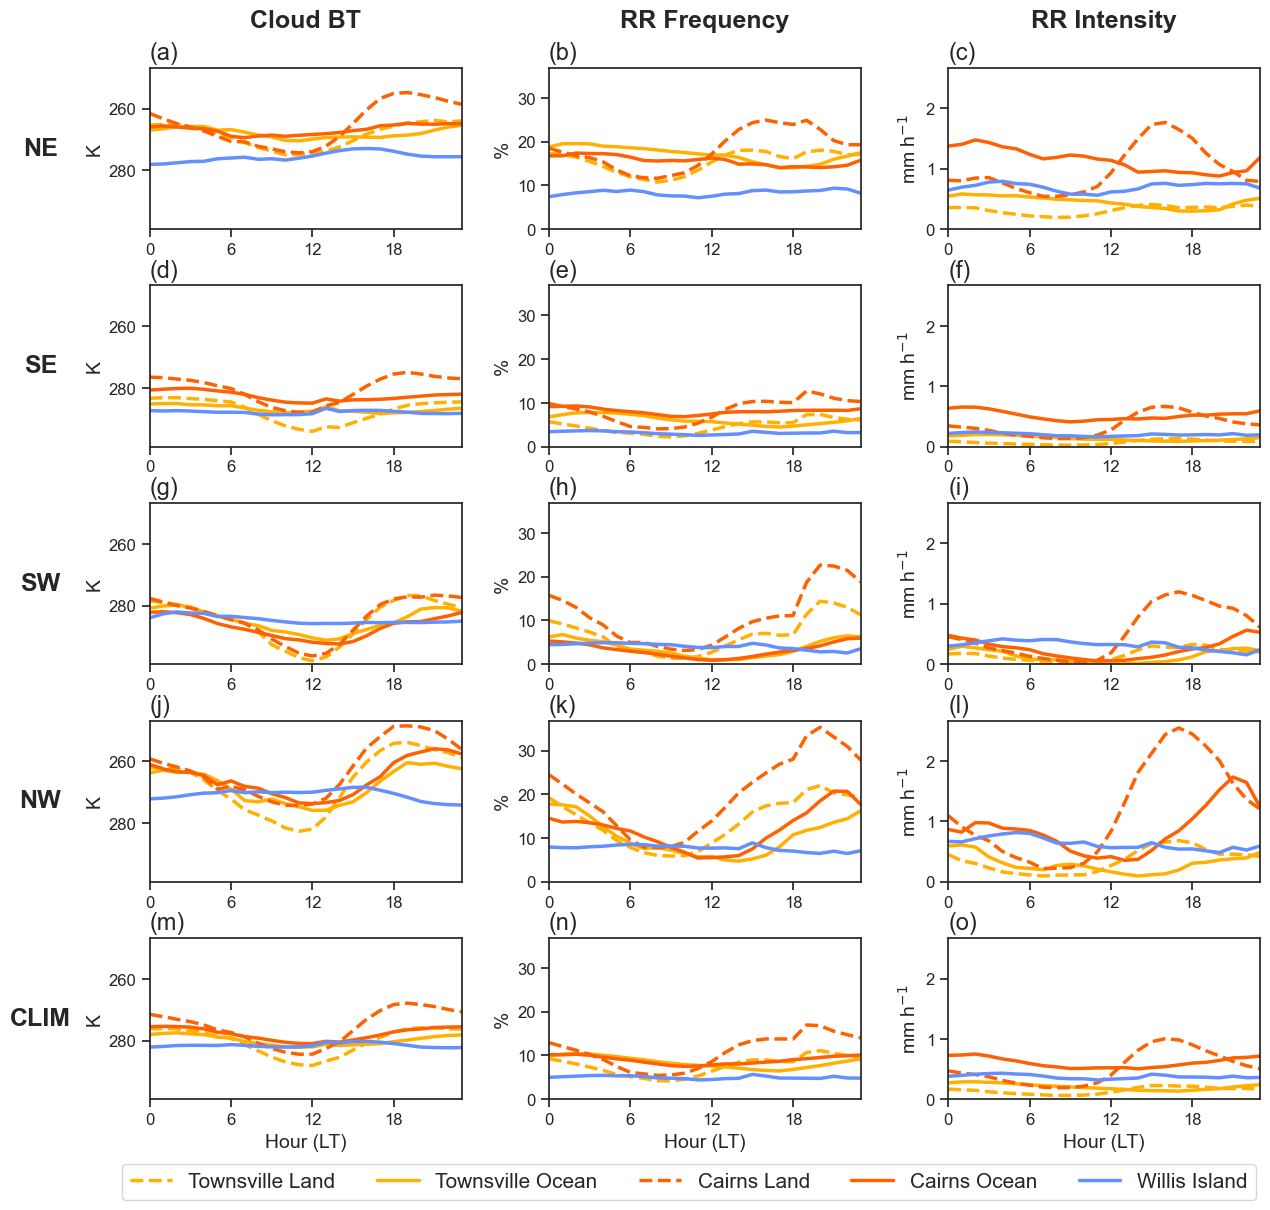

In [44]:
# with clim
# plot regime vs data (all sites within the same panels)
fig, axes = plt.subplots(5, 3, figsize=(12, 11))
fig.tight_layout()
sns.set_theme(style="ticks")
fig.subplots_adjust(
    hspace=0.35,  # vertical spacing between rows
    wspace=0.28   # horizontal spacing between columns
)
hours = np.arange(0, 24, 1)

titles        = ['Cloud BT', 'RR Frequency', 'RR Intensity']
regime_labels = ['NE', 'SE', 'SW', 'NW','CLIM']
regimes       = ['ne', 'se', 'sw', 'nw','clim']

# Okabe-Ito colorblind-friendly palette
site_colors = {
    'towns':  '#FFB000',
    'cairns': '#FE6100',
    'willis': '#648FFF',
}

# (label, bt_key, freq_dict, mean_dict, lon, linestyle)
series_cfg = [
    ('Townsville Land',  'towns_land',   Tland_freq,        Tland,        lon_t, '--', 'towns'),
    ('Townsville Ocean', 'towns_ocean',  Tocean_freq,       Tocean,       lon_t, '-',  'towns'),
    ('Cairns Land',      'cairns_land',  land_freq,         land,         lon_c, '--', 'cairns'),
    ('Cairns Ocean',     'cairns_ocean', ocean_freq,        ocean,        lon_c, '-',  'cairns'),
    ('Willis Island',    'willis_ocean', willis_ocean_freq, willis_ocean, lon_w, '-',  'willis'),
]

# ── Column titles ─────────────────────────────────────────────────────────────
for col, title in enumerate(titles):
    axes[0, col].set_title(title, fontsize=18,y=1.2, pad=15, weight='bold')

# ── Formatting ────────────────────────────────────────────────────────────────
for row in range(5):
    for col in range(3):
        letter = chr(97 + row * 3 + col)
        axes[row, col].set_title(f'({letter})', loc='left', fontsize=17)
        axes[row, col].set_xlim(0, 23)
        axes[row, col].set_xticks(np.arange(0, 24, 6))
        axes[row, col].tick_params(labelsize=12)
        if row == 4:
            axes[row, col].set_xlabel('Hour (LT)', fontsize=14)

    axes[row, 0].set_ylabel('K',            fontsize=14)
    axes[row, 1].set_ylabel('%',            fontsize=14)
    axes[row, 2].set_ylabel('mm h$^{-1}$', fontsize=14)

    # Regime label to the left of col-0
    axes[row, 0].text(
        x=-0.35, y=0.5, s=regime_labels[row],
        fontsize=18, ha='center', va='center',
        rotation=0, transform=axes[row, 0].transAxes,
        weight='bold',
    )

# ── Plot ──────────────────────────────────────────────────────────────────────
for row, regime in enumerate(regimes):
    for label, bt_key, freq_dict, mean_dict, lon, ls, site in series_cfg:
        col   = site_colors[site]
        bt_v  = bt[bt_key][regime].values
        frq_v = utc_hour_to_lst(freq_dict[regime], lon).values
        rr_v  = utc_hour_to_lst(mean_dict[regime], lon).values

        kw = dict(color=col, lw=2.5, linestyle=ls,
                  label=label if row == 0 else '_nolegend_')

        axes[row, 0].plot(hours, bt_v,  **kw)
        axes[row, 1].plot(hours, frq_v, **kw)
        axes[row, 2].plot(hours, rr_v,  **kw)

# ── Shared y-limits, BT inverted ─────────────────────────────────────────────
bt_min   = min(axes[r, 0].get_ylim()[0] for r in range(5))
bt_max   = max(axes[r, 0].get_ylim()[1] for r in range(5))
freq_max = max(axes[r, 1].get_ylim()[1] for r in range(5))
rr_max   = max(axes[r, 2].get_ylim()[1] for r in range(5))

for row in range(5):
    axes[row, 0].set_ylim(bt_max, bt_min)
    axes[row, 1].set_ylim(0, freq_max)
    axes[row, 2].set_ylim(0, rr_max)

# ── Legend ────────────────────────────────────────────────────────────────────
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color=site_colors['towns'],  lw=2.5, ls='--', label='Townsville Land'),
    Line2D([0], [0], color=site_colors['towns'],  lw=2.5, ls='-',  label='Townsville Ocean'),
    Line2D([0], [0], color=site_colors['cairns'], lw=2.5, ls='--', label='Cairns Land'),
    Line2D([0], [0], color=site_colors['cairns'], lw=2.5, ls='-',  label='Cairns Ocean'),
    Line2D([0], [0], color=site_colors['willis'], lw=2.5, ls='-',  label='Willis Island'),
]

fig.legend(
    handles=legend_elements,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.06),
    fontsize=15,
    ncol=5,
    frameon=True,
)

fig.savefig(
    '/home/563/ac9768/GBR/scripts/Paper_figures/f11_regimes.png',
    bbox_inches='tight', dpi=300,
)
plt.show()

In [19]:
BASE = '/home/563/ac9768/GBR/scripts/Paper_figures/Fig6_12LST_windregime_def'
sites   = ['cairns', 'willis']
subsite = ['land', 'ocean']
regimes = ['nw', 'ne', 'se', 'sw']
stat = ['mean_rainrate', 'freq']

# Build paths
radar_paths = {
    site: {
        regime: {
            sub: {
                st: f"{BASE}/{site}_{regime}_{sub}_{st}.zarr"
                for st in stat
            }
            for sub in subsite
        }
        for regime in regimes
    }
    for site in sites
}

lon_coords = {
    'cairns': xr.open_dataarray('/home/563/ac9768/GBR/scripts/Paper_figures/radar_anc/cairns_radar_lon.nc').values,
    'willis': xr.open_dataarray('/home/563/ac9768/GBR/scripts/Paper_figures/radar_anc/willis_radar_lon.nc').values,
}
lon_centers = {
    'cairns': (144.27374 + 147.09222) / 2,
    'willis': (148.55927 + 151.36993) / 2,
}

def open_rr(path: str, lon_center: float, lon_x: np.ndarray) -> xr.DataArray:
    """Open rain rate intensity and frequency zarr, shift to LST, roll."""
    offset_hours = round(lon_center * 4 / 60)
    ds = xr.open_zarr(path, chunks='auto')

    # Roll data AND coords together by the LST offset
    ds = ds.roll(hour=offset_hours, roll_coords=False)

    return ds

# Open all zarr
results = {
    site: {
        regime: {
            sub: {
                st: open_rr(
                    radar_paths[site][regime][sub][st],
                    lon_centers[site],
                    lon_coords[site]
                )
                for st in stat
                if os.path.exists(radar_paths[site][regime][sub][st])
            }
            for sub in subsite
        }
        for regime in regimes
    }
    for site in sites
}

(0.0, 23.0)

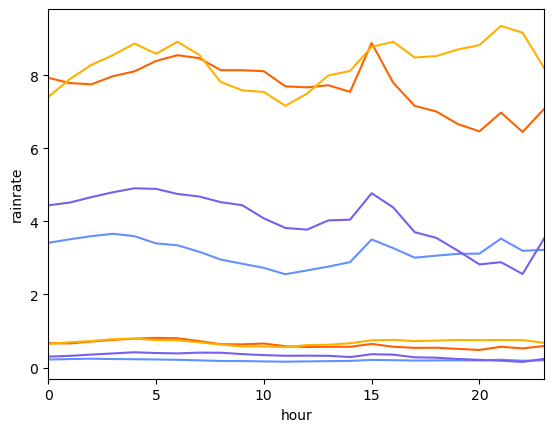

In [36]:
# colors  = {'ne': '#FFB000', 'se': '#648FFF', 'sw': '#785EF0', 'nw': '#FE6100'}
results['willis']['nw']['ocean']['freq'].freq.plot(color='#FE6100')
results['willis']['ne']['ocean']['freq'].freq.plot(color='#FFB000')
results['willis']['se']['ocean']['freq'].freq.plot(color='#648FFF')
results['willis']['sw']['ocean']['freq'].freq.plot(color='#785EF0')

results['willis']['nw']['ocean']['mean_rainrate'].rainrate.plot(color='#FE6100')
results['willis']['ne']['ocean']['mean_rainrate'].rainrate.plot(color='#FFB000')
results['willis']['se']['ocean']['mean_rainrate'].rainrate.plot(color='#648FFF')
results['willis']['sw']['ocean']['mean_rainrate'].rainrate.plot(color='#785EF0')

# plt.ylim(0,2.5)
plt.xlim(0,23)

In [35]:
cairns = '/scratch/v46/ac9768/radar/12LST_regime_definition/cairns_rainrate.zarr'
ds = xr.open_zarr(cairns, chunks='auto')

# define bb masks
mask_bb = xr.open_dataset('/home/563/ac9768/GBR/scripts/Paper_figures/radar_masks/bb_mask_cairns.nc').blockage_mask.drop_vars(['lat','lon'])
maskx = ds.x>-145.75

# ds.rainrate.where((mask_bb)&(maskx)).mean('time').plot()

In [38]:
def utc_hour_to_lst(da, longitude_center: float):
    offset_hours = round(longitude_center * 4 / 60)
    # print(offset_hours)
    da_lst = da.roll(hour=offset_hours)  # negative to shift forward in LST
    da_lst = da_lst.assign_coords(hour=(da_lst.hour % 24))
    da_lst = da_lst.sortby('hour')
    return da_lst

lon_centers = {
    'cairns': (144.27374 + 147.09222) / 2,
    'willis': (148.55927 + 151.36993) / 2,
}

In [11]:
regimes = ['ne', 'se', 'sw', 'nw']
colors  = {'ne': '#FFB000', 'se': '#648FFF', 'sw': '#785EF0', 'nw': '#FE6100'}
base    = '/home/563/ac9768/GBR/scripts/Paper_figures/Fig6_12LST_windregime_def'

ocean, land,  = {}, {} 

for regime in regimes:
    ocean[regime]     = xr.open_zarr(f'{base}/cairns_{regime}_ocean_mean_rainrate.zarr').rainrate
    land[regime]      = xr.open_zarr(f'{base}/cairns_{regime}_land_mean_rainrate.zarr').rainrate

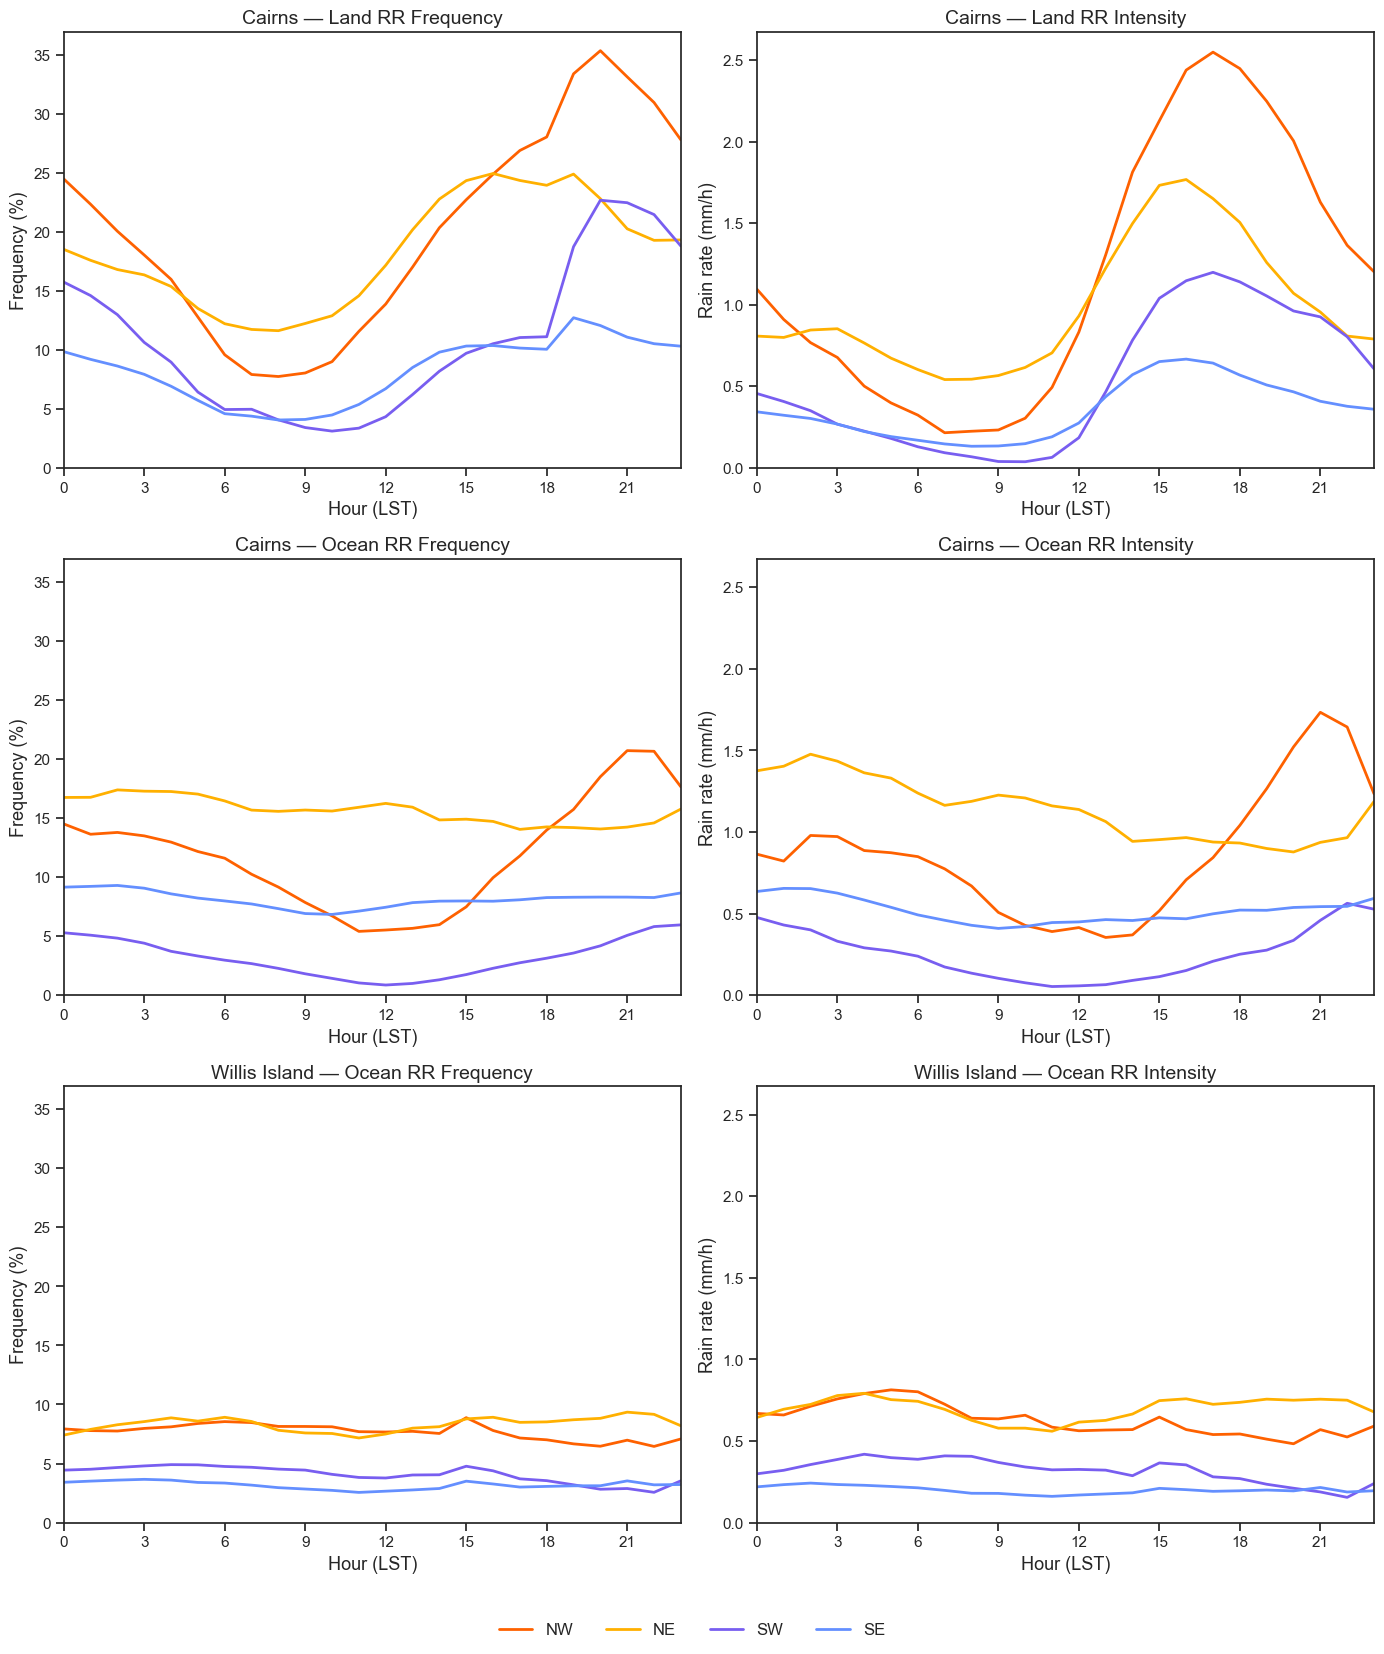

In [43]:
regimes = ['nw', 'ne', 'sw', 'se']
colors  = {'nw': '#FE6100', 'ne': '#FFB000', 'sw': '#785EF0', 'se': '#648FFF'}
base    = '/home/563/ac9768/GBR/scripts/Paper_figures/Fig6_12LST_windregime_def'

ocean, land, ocean_freq, land_freq = {}, {}, {}, {}
willis_ocean, willis_ocean_freq = {}, {}

for regime in regimes:
    ocean[regime]      = xr.open_zarr(f'{base}/cairns_{regime}_ocean_mean_rainrate.zarr').rainrate
    land[regime]       = xr.open_zarr(f'{base}/cairns_{regime}_land_mean_rainrate.zarr').rainrate
    ocean_freq[regime] = xr.open_zarr(f'{base}/cairns_{regime}_ocean_freq.zarr').freq
    land_freq[regime]  = xr.open_zarr(f'{base}/cairns_{regime}_land_freq.zarr').freq
    willis_ocean[regime]      = xr.open_zarr(f'{base}/willis_{regime}_ocean_mean_rainrate.zarr').rainrate
    willis_ocean_freq[regime] = xr.open_zarr(f'{base}/willis_{regime}_ocean_freq.zarr').freq

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
sns.set_theme(style="ticks")

lon_c = lon_centers['cairns']
lon_w = lon_centers['willis']
hours = np.arange(0, 24, 1)

for regime, color in colors.items():
    # cairns
    freq_l = utc_hour_to_lst(land_freq[regime],  lon_c).values
    mean_l = utc_hour_to_lst(land[regime],        lon_c).values
    freq_o = utc_hour_to_lst(ocean_freq[regime],  lon_c).values
    mean_o = utc_hour_to_lst(ocean[regime],       lon_c).values
    # willis
    freq_wo = utc_hour_to_lst(willis_ocean_freq[regime], lon_w).values
    mean_wo = utc_hour_to_lst(willis_ocean[regime],      lon_w).values

    axes[0, 0].plot(hours, freq_l,  color=color, linewidth=2, label=regime.upper())
    axes[0, 1].plot(hours, mean_l,  color=color, linewidth=2, label=regime.upper())
    axes[1, 0].plot(hours, freq_o,  color=color, linewidth=2, label=regime.upper())
    axes[1, 1].plot(hours, mean_o,  color=color, linewidth=2, label=regime.upper())
    axes[2, 0].plot(hours, freq_wo, color=color, linewidth=2, label=regime.upper())
    axes[2, 1].plot(hours, mean_wo, color=color, linewidth=2, label=regime.upper())

panel_titles = [
    ['Cairns — Land RR Frequency',    'Cairns — Land RR Intensity'],
    ['Cairns — Ocean RR Frequency',   'Cairns — Ocean RR Intensity'],
    ['Willis Island — Ocean RR Frequency', 'Willis Island — Ocean RR Intensity'],
]
ylabels = ['Frequency (%)', 'Rain rate (mm/h)']

for row in range(3):
    for col in range(2):
        axes[row, col].set_xlim(0, 23)
        axes[row, col].set_xticks(np.arange(0, 24, 3))
        axes[row, col].set_xlabel('Hour (LST)', fontsize=13)
        axes[row, col].set_title(panel_titles[row][col], fontsize=14)
        axes[row, col].tick_params(labelsize=11)
    axes[row, 0].set_ylabel(ylabels[0], fontsize=13)
    axes[row, 1].set_ylabel(ylabels[1], fontsize=13)

# collect y limits across all freq and rainrate panels
freq_panels  = [axes[0, 0], axes[1, 0], axes[2, 0]]
rr_panels    = [axes[0, 1], axes[1, 1], axes[2, 1]]

freq_ymax = max(ax.get_ylim()[1] for ax in freq_panels)
rr_ymax   = max(ax.get_ylim()[1] for ax in rr_panels)

for ax in freq_panels:
    ax.set_ylim(0, freq_ymax)
for ax in rr_panels:
    ax.set_ylim(0, rr_ymax)
# hide unused 4th row
# axes[3, 0].set_visible(False)
# axes[3, 1].set_visible(False)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.01),
           ncol=4, frameon=False, fontsize=12)

plt.tight_layout()
plt.show()

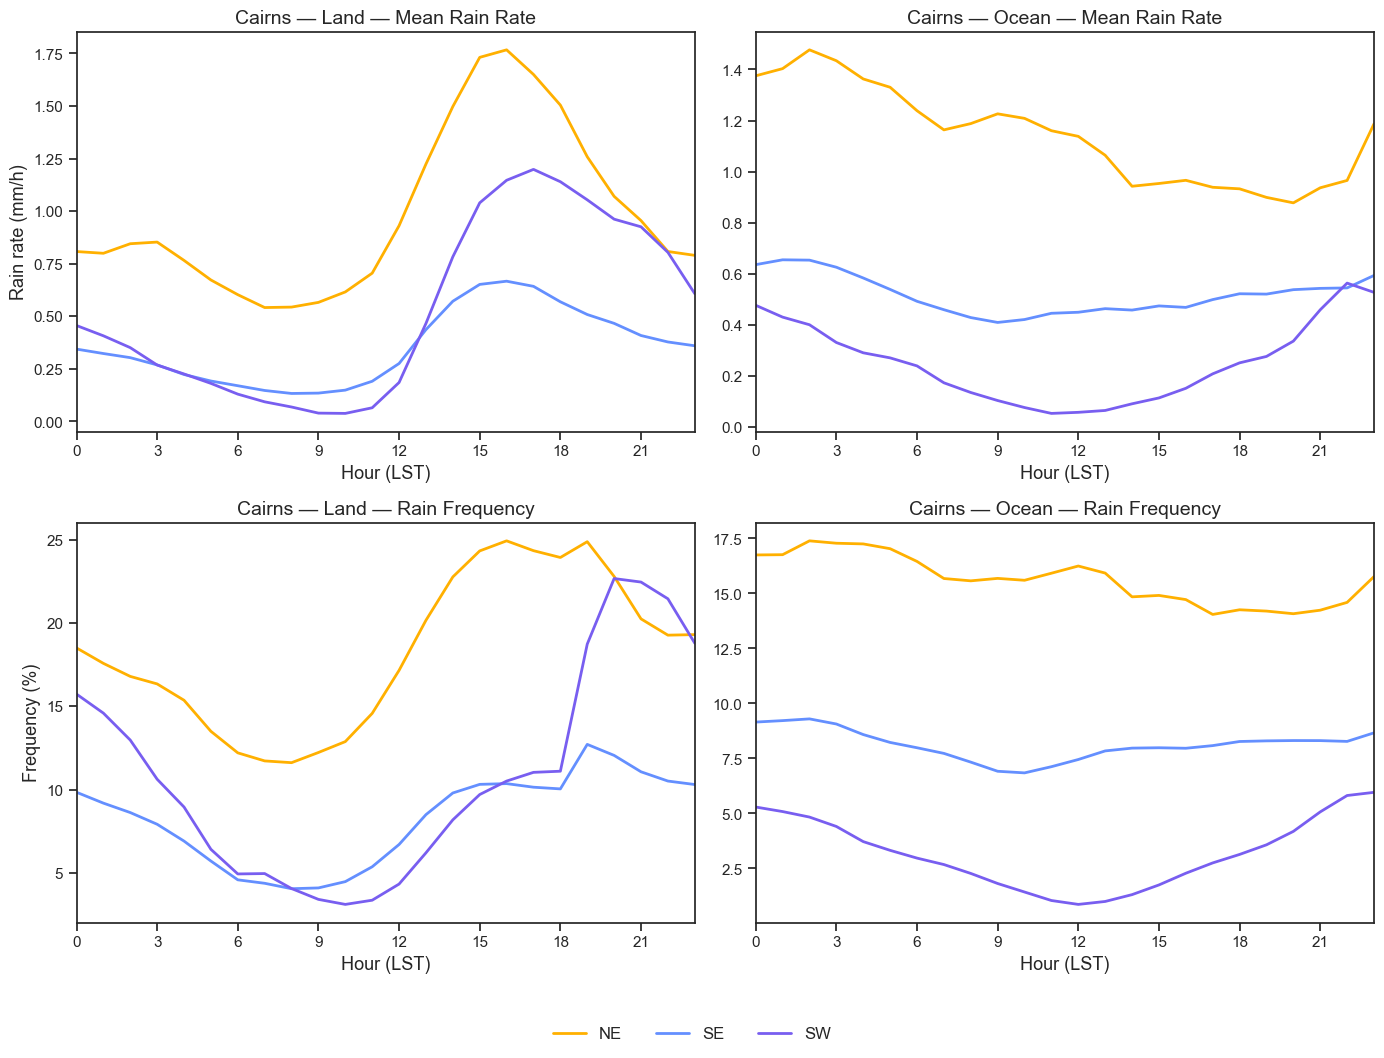

In [9]:
regimes = ['ne', 'se', 'sw']#, 'nw']
colors  = {'ne': '#FFB000', 'se': '#648FFF','sw': '#785EF0', }#'nw': '#FE6100'}
base    = '/home/563/ac9768/GBR/scripts/Paper_figures/Fig6_12LST_windregime_def'

ocean, land, ocean_freq, land_freq = {}, {}, {}, {}

for regime in regimes:
    ocean[regime]      = xr.open_zarr(f'{base}/cairns_{regime}_ocean_mean_rainrate.zarr').rainrate
    land[regime]       = xr.open_zarr(f'{base}/cairns_{regime}_land_mean_rainrate.zarr').rainrate
    ocean_freq[regime] = xr.open_zarr(f'{base}/cairns_{regime}_ocean_freq.zarr').freq
    land_freq[regime]  = xr.open_zarr(f'{base}/cairns_{regime}_land_freq.zarr').freq

# --- plot ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.set_theme(style="ticks")

lon   = lon_centers['cairns']
hours = np.arange(0, 24, 1)

for regime, color in colors.items():
    mean_o = utc_hour_to_lst(ocean[regime],      lon).values
    mean_l = utc_hour_to_lst(land[regime],       lon).values
    freq_o = utc_hour_to_lst(ocean_freq[regime], lon).values
    freq_l = utc_hour_to_lst(land_freq[regime],  lon).values

    axes[0, 0].plot(hours, mean_l, color=color, linewidth=2, label=regime.upper())
    axes[0, 1].plot(hours, mean_o, color=color, linewidth=2, label=regime.upper())
    axes[1, 0].plot(hours, freq_l, color=color, linewidth=2, label=regime.upper())
    axes[1, 1].plot(hours, freq_o, color=color, linewidth=2, label=regime.upper())

titles = [['Cairns land — RR intensity', 'Cairns ocean — RR intensity'],
          ['Cairns land — RR Frequency', 'Cairns ocean — RR Frequency']]
ylabels = ['Rain rate (mm/h)', 'Frequency (%)']

for row in range(2):
    for col in range(2):
        axes[row, col].set_xlim(0, 23)
        axes[row, col].set_xticks(np.arange(0, 24, 3))
        axes[row, col].set_xlabel('Hour (LST)', fontsize=13)
        axes[row, col].set_title(f'Cairns — {titles[row][col]}', fontsize=14)
        axes[row, col].tick_params(labelsize=11)
    axes[row, 0].set_ylabel(ylabels[row], fontsize=13)

# shared legend below
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.02),
           ncol=4, frameon=False, fontsize=12)

plt.tight_layout()
plt.show()

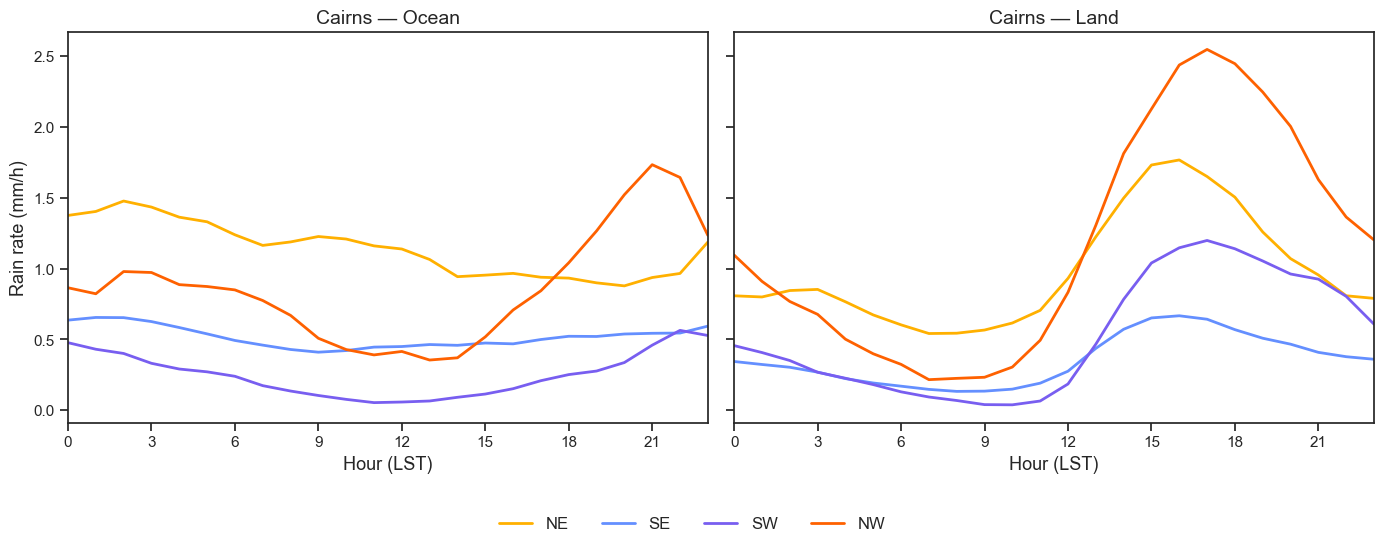

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
sns.set_theme(style="ticks")

lon = lon_centers['cairns']
hours = np.arange(0, 24, 1)

for regime, color in colors.items():
    # --- ocean ---
    mean_o = utc_hour_to_lst(ocean[regime], lon).values
    # q25_o  = utc_hour_to_lst(ocean_q25[regime], lon).values
    # q75_o  = utc_hour_to_lst(ocean_q75[regime], lon).values

    axes[0].plot(hours, mean_o, color=color, linewidth=2, label=regime.upper())
    # axes[0].fill_between(hours, q25_o, q75_o, color=color, alpha=0.15)

    # --- land ---
    mean_l = utc_hour_to_lst(land[regime], lon).values
    # q25_l  = utc_hour_to_lst(land_q25[regime], lon).values
    # q75_l  = utc_hour_to_lst(land_q75[regime], lon).values

    axes[1].plot(hours, mean_l, color=color, linewidth=2, label=regime.upper())
    # axes[1].fill_between(hours, q25_l, q75_l, color=color, alpha=0.15)

for ax, title in zip(axes, ['Ocean', 'Land']):
    ax.set_xlim(0, 23)
    ax.set_xticks(np.arange(0, 24, 3))
    ax.set_xlabel('Hour (LST)', fontsize=13)
    ax.set_title(f'Cairns — {title}', fontsize=14)
    ax.tick_params(labelsize=11)

axes[0].set_ylabel('Rain rate (mm/h)', fontsize=13)

# shared legend below
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.02),
           ncol=4, frameon=False, fontsize=12)

plt.tight_layout()
plt.show()

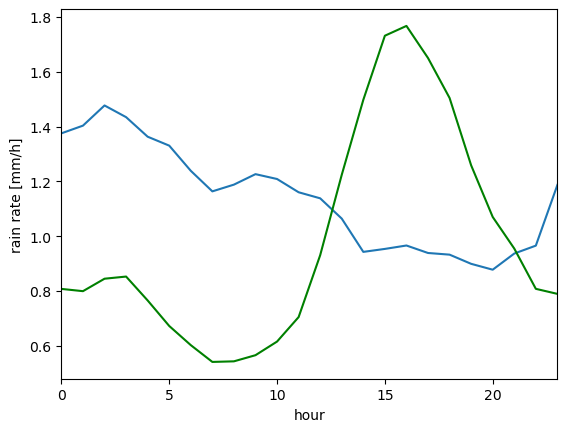

In [55]:
cairnsocean_ne = '/home/563/ac9768/GBR/scripts/Paper_figures/Fig6_12LST_windregime_def/cairns_ne_ocean_mean_rainrate.zarr'
cairnsland_ne = '/home/563/ac9768/GBR/scripts/Paper_figures/Fig6_12LST_windregime_def/cairns_ne_land_mean_rainrate.zarr'
ds = xr.open_zarr(cairnsocean_ne, chunks='auto')
ds_ = xr.open_zarr(cairnsland_ne, chunks='auto')

utc_hour_to_lst(ds.rainrate,lon_centers['cairns']).plot()
utc_hour_to_lst(ds_.rainrate,lon_centers['cairns']).plot(color='green')
plt.xlim(0,23)
plt.show()

In [ ]:
def wind_times(barra_regime_ds: xr.Dataset, longitude_center: float):
    """
    Classify wind direction at LST solar noon (hour=12), then assign
    all hours of that day to the same wind regime.

    Args:
        barra_regime_ds:  xarray Dataset with 'wind_dir' and 'time' dimension.
        longitude_center: Representative longitude for LST conversion.

    Returns:
        ne, se, sw, nw: arrays of datetime64 timestamps (all hours) 
                        belonging to each wind regime day.
    """
    # 1. Shift full dataset to LST
    ds_lst = utc_to_lst_shift(barra_regime_ds, longitude_center)

    # 2. Extract wind_dir and compute (needed for boolean indexing)
    winds = ds_lst.wind_dir.compute()

    # 3. Select only solar noon (LST hour=12) for regime classification
    winds_noon = winds.sel(time=winds.time.dt.hour == 12)

    # 4. Classify noon wind direction → get dates (not full timestamps)
    ne_dates = winds_noon.time.values[(winds_noon.values >= 0)   & (winds_noon.values <= 90)]
    se_dates = winds_noon.time.values[(winds_noon.values > 90)   & (winds_noon.values <= 180)]
    sw_dates = winds_noon.time.values[(winds_noon.values > 180)  & (winds_noon.values <= 270)]
    nw_dates = winds_noon.time.values[(winds_noon.values > 270)  & (winds_noon.values <= 360)]

    # 5. Convert noon timestamps → date-only for day matching
    def noon_to_all_hours(regime_noon_times):
        """Given noon timestamps, return all LST timestamps on those days."""
        regime_dates = set(
            pd.Timestamp(t).date() for t in regime_noon_times
        )
        all_times = pd.DatetimeIndex(winds.time.values)
        mask = all_times.normalize().map(lambda d: d.date() in regime_dates)
        return winds.time.values[mask]

    ne_lst = noon_to_all_hours(ne_dates)
    se_lst = noon_to_all_hours(se_dates)
    sw_lst = noon_to_all_hours(sw_dates)
    nw_lst = noon_to_all_hours(nw_dates)

    # 6. Convert LST timestamps back to UTC by subtracting the offset
    offset_hours = round(longitude_center * 4 / 60)
    offset = pd.Timedelta(hours=offset_hours)

    # Shift only the time coordinate labels, data values stay aligned
    # ds_lst = ds.assign_coords(time=ds.time + offset)

    
    # offset_hours = round(longitude_center * 4 / 60)
    # offset = np.timedelta64(offset_hours, 'h')

    ne = ne_lst - offset
    se = se_lst - offset
    sw = sw_lst - offset
    nw = nw_lst - offset

    return ne, se, sw, nw


# --- Usage ---
lon_towns  = (145.12054 + 147.9812)  / 2  # ≈ 146.55°E
lon_cairns = (144.27374 + 147.09222) / 2  # ≈ 145.68°E
lon_willis = (148.55927 + 151.36993) / 2

ne_towns,  se_towns,  sw_towns,  nw_towns  = wind_times(barra_towns,  lon_towns)
ne_cairns, se_cairns, sw_cairns, nw_cairns = wind_times(barra_cairns, lon_cairns)
ne_willis, se_willis, sw_willis, nw_willis = wind_times(barra_willis, lon_willis)

# Calculate rain rate intensity diurnal cycle

In [3]:
def process_hour_int(ds):
    """
    Sum the number of non raining points (value = 0) across x, y and time ignoring Nans. Sum the
    number of raining points. Compute those values. Calculate the total of valid data points (raining + non-raining). Calculate the frequency
    where the number of raining points is divided by the total valid points * 100.
    
    Parameters:
    - ds (str): Path to the netCDF file(s).
    
    Returns:
    - int: Intensity of raining points (mm/h)
    """
    
    intensity = ds.mean(dim=["time",'x','y'],skipna=True) 
    return intensity

In [6]:
%%time
cairns_land = create_radar_mask(cairns_radar_files, 1.2,land=True,ocean=False)

bathymetry
<xarray.DataArray 'rainrate' ()> Size: 8B
array(68365)
calculated mean rr
CPU times: user 27min 36s, sys: 4min 32s, total: 32min 8s
Wall time: 20min 41s


In [5]:
%%time
cairns_ocean = create_radar_mask(cairns_radar_files, 1.2,land=False,ocean=True)

bathymetry
<xarray.DataArray 'rainrate' ()> Size: 8B
array(68365)
calculated mean rr
CPU times: user 30min 9s, sys: 4min 33s, total: 34min 43s
Wall time: 23min 12s


<xarray.DataArray 'rainrate' ()> Size: 8B
array(68365)
calculated mean rr
CPU times: user 30min 9s, sys: 6min 9s, total: 36min 18s
Wall time: 24min 7s


In [17]:
willis_mask = create_radar_mask(willis_radar_files, 1.2,land=False,ocean=False)

bathymetry
<xarray.DataArray 'rainrate' ()> Size: 8B
array(65836)
calculated mean rr


In [7]:
%%time
towns_land = create_radar_mask(towns_radar_files, 0.8,land=True,ocean=False)

bathymetry
<xarray.DataArray 'rainrate' ()> Size: 8B
array(70616)
calculated mean rr
CPU times: user 23min 18s, sys: 3min 38s, total: 26min 56s
Wall time: 17min 59s


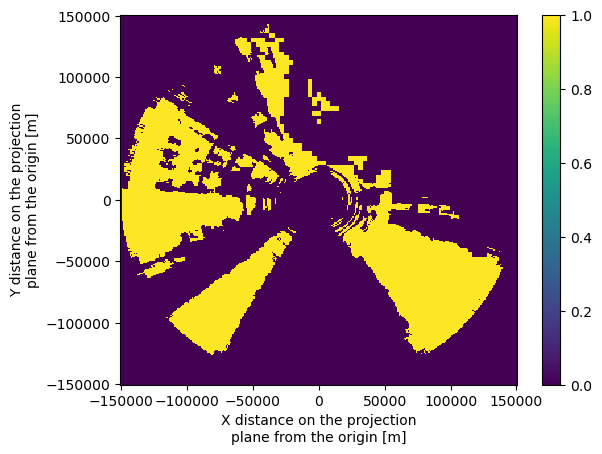

In [7]:
towns_land.plot()

In [9]:
towns_ocean = create_radar_mask(towns_radar_files, 0.8,land=False,ocean=True)

bathymetry
<xarray.DataArray 'rainrate' ()> Size: 8B
array(70616)
calculated mean rr


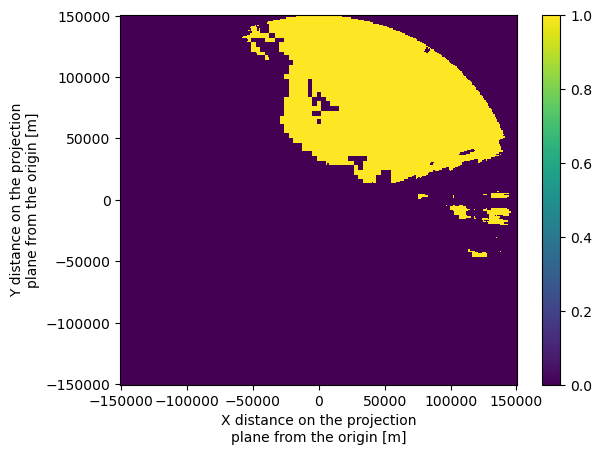

In [9]:
towns_ocean.plot()

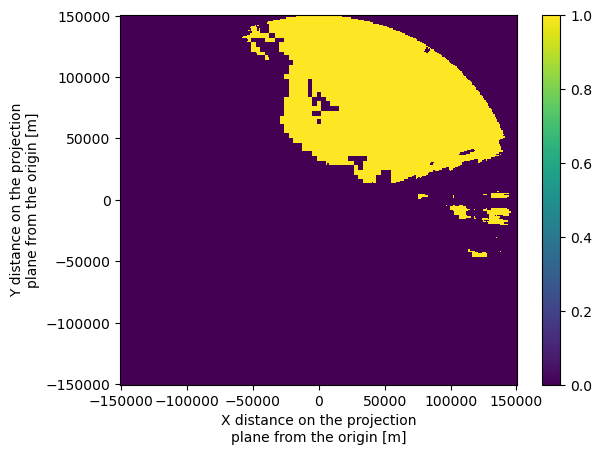

In [10]:
towns_ocean.plot()

In [18]:
def open_radar(file_path):
    with xr.open_mfdataset(file_path, engine="h5netcdf", chunks="auto") as ds:            
        nan_to_zero = ds.rainrate.fillna(0) # creates a much lower mean threshold (if used for masking) - includes non raining periods           
        return ds,nan_to_zero
    
# entire_radar_dsC,nan_filled_dsC = open_radar(cairns_radar_files)
# entire_radar_ds,nan_filled_ds = open_radar(towns_radar_files)
entire_radar_dsW,nan_filled_dsW = open_radar(willis_radar_files)

# apply the masks created above
# masked_ds_land = nan_filled_dsC.where(cairns_land)
# masked_ds_ocean = nan_filled_dsC.where(cairns_ocean)
# masked_ds_landT = nan_filled_ds.where(towns_land)
# masked_ds_oceanT = nan_filled_ds.where(towns_ocean)
mask_willis = nan_filled_dsW.where(willis_mask)

In [19]:
def radar_variable_isfile_mask(entire_radar_dataset,masked_radar_ds):
    qc = entire_radar_dataset.isfile.compute()[entire_radar_dataset.isfile.compute()>0] # when greater than 0: valid time-step
    final_mask = masked_radar_ds.where(qc)
    return final_mask
# masked_land_dsC = radar_variable_isfile_mask(entire_radar_dsC,masked_ds_land)
# masked_ocean_dsC = radar_variable_isfile_mask(entire_radar_dsC,masked_ds_ocean)
# masked_land_dsT = radar_variable_isfile_mask(entire_radar_ds,masked_ds_landT)
# masked_ocean_dsT = radar_variable_isfile_mask(entire_radar_ds,masked_ds_oceanT)
masked_willis = radar_variable_isfile_mask(entire_radar_dsW,mask_willis)

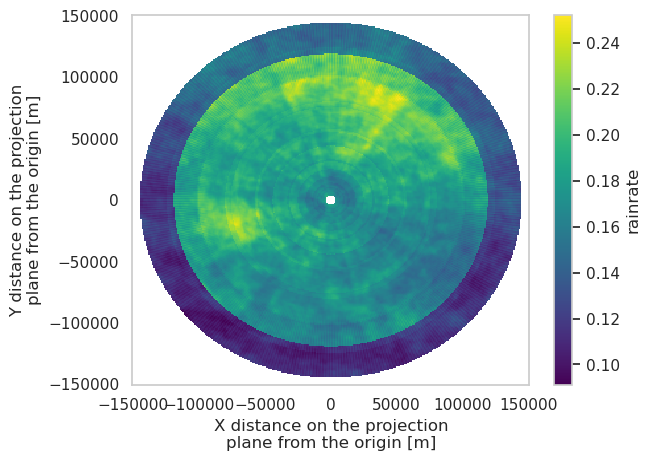

In [45]:
mask_willis.mean('time').plot()

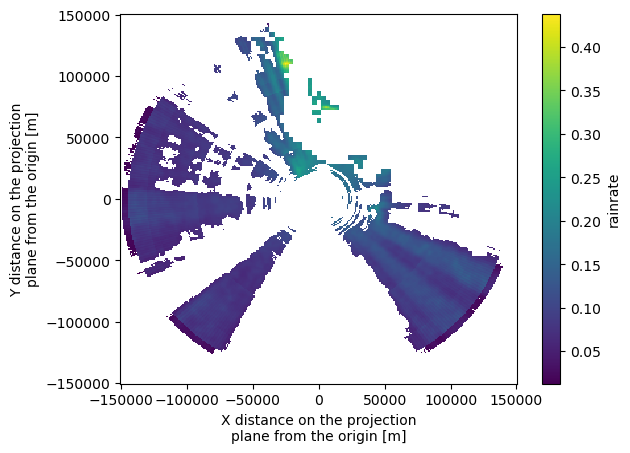

In [13]:
masked_ds_land.mean(['time']).plot()

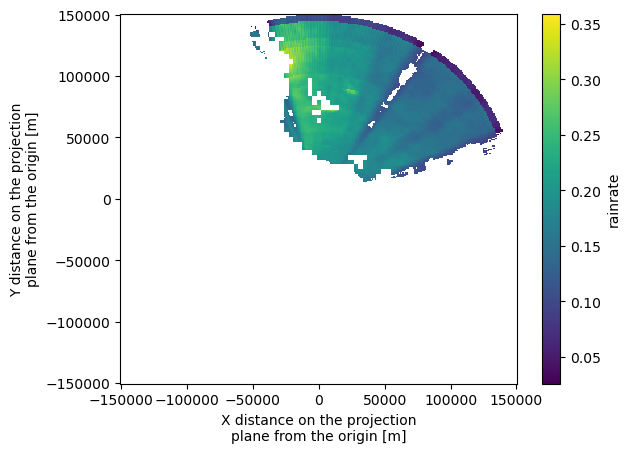

In [10]:
masked_ds_ocean.mean(['time']).plot()

In [ ]:
def generate_diurnal_ds(ds,wind_dir,wind_dir1,wind_dir2,ne=None):
    # select wind directions
    winds = wind_dir.wind_dir.compute()
    if ne==True:
        wind = winds[(winds>=wind_dir1)&(winds<=wind_dir2)]
    else:
        wind = winds[(winds>wind_dir1)&(winds<=wind_dir2)]

    # select wind time values
    wind = wind.drop_duplicates(dim="time")
    wind_times = wind.time.values
    wind_times.sort() 
    print(len(wind_times))

    # Define the time window of 30 minutes - to select radar data +30/-30min of selected BARRA2 wind direction hour
    window_size = pd.Timedelta(minutes=30)
    
    # Initialize empty list to store selected data
    selected_data = []
    # Loop through each time point in wind (directions chosen above); or for deep easterlies, through: wind_speed_SE_10ms
    for time in wind_times:
        # Calculate the start and end times of the window
        window_start = time - window_size
        window_end = time + window_size
        # Select the data within the time window from ds2 using slice
        data_within_window = ds.sel(time=slice(window_start, window_end))
        # Append the selected data to the list
        selected_data.append(data_within_window)
        
    # Concatenate the selected data into a single xarray dataset
    radar_composite_winds = xr.concat(selected_data, dim='time').drop_duplicates(dim="time")
    print(len(radar_composite_winds.time))
    intensity = radar_composite_winds.groupby(radar_composite_winds.time.dt.hour).apply(process_hour_int)
    return intensity

In [9]:
def save_as_zarray(file_path,ds):
    save_file_path = file_path
    ds.to_zarr(save_file_path)
    return

In [10]:
# open barra 850 hPa wind datasets
barra_towns = xr.open_dataset("/home/563/ac9768/GBR/barra-2/barra-2_850hPa_winds_townsville.nc", engine="h5netcdf",chunks="auto")
barra_cairns = xr.open_dataset("/home/563/ac9768/GBR/barra-2/barra-2_850hPa_winds_cairns.nc", engine="h5netcdf",chunks="auto")
barra_willis = xr.open_dataset("/home/563/ac9768/GBR/barra-2/barra-2_850hPa_winds_willis_island.nc", engine="h5netcdf",chunks="auto")

In [24]:
%%time
# ne = generate_diurnal_ds(masked_willis,barra_willis,0,90,ne=True) 
# se = generate_diurnal_ds(masked_willis,barra_willis,90,180,ne=False)
# sw = generate_diurnal_ds(masked_willis,barra_willis,180,270,ne=False)
# nw = generate_diurnal_ds(masked_willis,barra_willis,270,360,ne=False)
clim = generate_diurnal_ds(masked_ocean_dsC,barra_cairns,0,360,ne=True)

file_save_name = 'rr_intensity_willis_ocean_clim'
save_as_zarray("/home/563/ac9768/GBR/radar/"+file_save_name+".zarr",clim)

30288
257872
CPU times: user 28min 26s, sys: 4min 57s, total: 33min 24s
Wall time: 19min 5s


# Calculate rain rate frequency diurnal cycle

In [20]:
def utc_to_lst_shift(ds, longitude_center: float):
    """
    Shift xarray data from UTC to Local Solar Time by offsetting the 
    time coordinate. Adds the LST offset to time labels directly —
    does NOT roll/wrap data values.

    Args:
        ds:               xarray Dataset or DataArray with a 'time' dimension.
        longitude_center: Representative longitude of the region (decimal degrees).

    Returns:
        Dataset/DataArray with time coordinate relabelled to LST.
    """
    offset_hours = round(longitude_center * 4 / 60)
    offset = pd.Timedelta(hours=offset_hours)

    # Shift only the time coordinate labels, data values stay aligned
    ds_lst = ds.assign_coords(time=ds.time + offset)
    return ds_lst

In [21]:
def wind_times(barra_regime_ds: xr.Dataset, longitude_center: float):
    """
    Classify wind direction at LST solar noon (hour=12), then assign
    all hours of that day to the same wind regime.

    Args:
        barra_regime_ds:  xarray Dataset with 'wind_dir' and 'time' dimension.
        longitude_center: Representative longitude for LST conversion.

    Returns:
        ne, se, sw, nw: arrays of datetime64 timestamps (all hours) 
                        belonging to each wind regime day.
    """
    # 1. Shift full dataset to LST
    ds_lst = utc_to_lst_shift(barra_regime_ds, longitude_center)

    # 2. Extract wind_dir and compute (needed for boolean indexing)
    winds = ds_lst.wind_dir.compute()

    # 3. Select only solar noon (LST hour=12) for regime classification
    winds_noon = winds.sel(time=winds.time.dt.hour == 12)

    # 4. Classify noon wind direction → get dates (not full timestamps)
    ne_dates = winds_noon.time.values[(winds_noon.values >= 0)   & (winds_noon.values <= 90)]
    se_dates = winds_noon.time.values[(winds_noon.values > 90)   & (winds_noon.values <= 180)]
    sw_dates = winds_noon.time.values[(winds_noon.values > 180)  & (winds_noon.values <= 270)]
    nw_dates = winds_noon.time.values[(winds_noon.values > 270)  & (winds_noon.values <= 360)]

    # 5. Convert noon timestamps → date-only for day matching
    def noon_to_all_hours(regime_noon_times):
        """Given noon timestamps, return all LST timestamps on those days."""
        regime_dates = set(
            pd.Timestamp(t).date() for t in regime_noon_times
        )
        all_times = pd.DatetimeIndex(winds.time.values)
        mask = all_times.normalize().map(lambda d: d.date() in regime_dates)
        return winds.time.values[mask]

    ne_lst = noon_to_all_hours(ne_dates)
    se_lst = noon_to_all_hours(se_dates)
    sw_lst = noon_to_all_hours(sw_dates)
    nw_lst = noon_to_all_hours(nw_dates)

    # 6. Convert LST timestamps back to UTC by subtracting the offset
    offset_hours = round(longitude_center * 4 / 60)
    offset = pd.Timedelta(hours=offset_hours)

    # Shift only the time coordinate labels, data values stay aligned
    # ds_lst = ds.assign_coords(time=ds.time + offset)

    
    # offset_hours = round(longitude_center * 4 / 60)
    # offset = np.timedelta64(offset_hours, 'h')

    ne = ne_lst - offset
    se = se_lst - offset
    sw = sw_lst - offset
    nw = nw_lst - offset

    return ne, se, sw, nw

barra_towns = xr.open_dataset("/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa_winds_townsville.nc", engine="h5netcdf",chunks="auto")
barra_cairns = xr.open_dataset("/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa_winds_cairns.nc", engine="h5netcdf",chunks="auto")
barra_willis = xr.open_dataset("/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa_winds_willis_island.nc", engine="h5netcdf",chunks="auto")

lon_centers = {
    'cairns': (144.27374 + 147.09222) / 2,
    'willis': (148.55927 + 151.36993) / 2,
}

In [22]:
cairns = '/scratch/v46/ac9768/radar/12LST_regime_definition/cairns_rainrate.zarr'
ds = xr.open_zarr(cairns, chunks='auto')

In [23]:
def process_hour_freq(ds):
    """
    Sum the number of non raining points (value = 0) across x, y and time ignoring Nans. Sum the
    number of raining points. Compute those values. Calculate the total of valid data points (raining + non-raining). Calculate the frequency
    where the number of raining points is divided by the total valid points * 100.
    
    Parameters:
    - ds (str): Path to the netCDF file(s).
    
    Returns:
    - int: Frequency of raining points (%)
    """
    total_points = (ds.rainrate == 0).where(~ds.rainrate.isnull()).count(dim=['time','x', 'y'])
    # number_of_nonraining_points = (ds == 0).where(~ds.isnull()).sum(dim=['x', 'y', 'time'])
    # number_of_raining_points = (ds != 0).where(~ds.isnull()).sum(dim=['x', 'y', 'time'])
    number_of_non_raining_points = ds.rainrate.where(((ds.rainrate>=0)&(ds.rainrate<0.001))).count(dim=['x', 'y', 'time'])
    # total_count = (number_of_nonraining_points) + (number_of_raining_points)
    total = (total_points) - (number_of_non_raining_points)
    freq = (total / total_points) * 100
    # freq = (number_of_raining_points / total_count) * 100
    return freq

In [28]:
def mask_radar_data(
    zarr_path: str,
    # land_mask_path: str = None,
    # ocean_mask_path: str = None,
    cairns: bool = False,
) -> tuple[xr.DataArray, xr.DataArray]:
    """
    Load zarr rainrate and apply beam blockage + land/ocean masks.
    Returns masked DataArrays for ocean and land separately.
    """
    ds = xr.open_zarr(zarr_path, chunks='auto').chunk({'time': 100, 'y': -1, 'x': -1})

    # beam blockage + x-extent mask (Cairns only)
    if cairns:
        bb_mask   = xr.open_dataset('/home/563/ac9768/GBR/scripts/Paper_figures/radar_masks/bb_mask_cairns.nc').blockage_mask.drop_vars(['lat', 'lon'])
        maskx     = ds.x > -145.75
        base_mask = bb_mask & maskx
    else:
        base_mask = xr.ones_like(ds.rainrate.isel(time=0), dtype=bool)

    # land/ocean masks
    land_mask  = xr.open_dataset('/home/563/ac9768/GBR/scripts/Paper_figures/radar_masks/bbANDland_mask_cairns.nc')[list(xr.open_dataset('/home/563/ac9768/GBR/scripts/Paper_figures/radar_masks/bbANDland_mask_cairns.nc').data_vars)[0]]
    ocean_mask = xr.open_dataset('/home/563/ac9768/GBR/scripts/Paper_figures/radar_masks/bbANDocean_mask_cairns.nc')[list(xr.open_dataset('/home/563/ac9768/GBR/scripts/Paper_figures/radar_masks/bbANDocean_mask_cairns.nc').data_vars)[0]]

    rr_ocean = ds.where(base_mask & land_mask)
    rr_land  = ds.where(base_mask & ocean_mask)

    return rr_ocean, rr_land


def get_freq_under_wind_regimes(radar_ds: xr.DataArray, regime_times: np.ndarray):
    """
    Select radar data within ±30min of each regime timestamp,
    fill NaN (no rain) with 0, then compute hourly rain frequency.

    Args:
        radar_ds:     (time, y, x) masked rain rate DataArray
        regime_times: array of UTC datetime64 timestamps for the regime

    Returns:
        xr.DataArray: hourly rain frequency (%) with dim 'hour'
    """
    window_size = np.timedelta64(30, 'm')
    all_times   = radar_ds.time.values.astype('datetime64[ns]')[:, None]
    reg_times   = pd.DatetimeIndex(regime_times).values.astype('datetime64[ns]')

    # vectorised window matching — no Python loop over time
    in_window = np.any(
        (all_times >= reg_times - window_size) &
        (all_times <= reg_times + window_size),
        axis=1,
    )

    selected = radar_ds.isel(time=in_window).drop_duplicates(dim='time')

    # fill NaN → 0 (non-raining); NaN only where mask excluded pixels
    # selected = selected.fillna(0).where(selected.notnull() | selected.isnull())

    result = selected.drop_vars(['lat','lon']).groupby('time.hour')
    print(result)
    result = result.apply(process_hour_freq)
    # for h in hours:
    #     hour_data = selected.sel(time=selected.time.dt.hour == h)
    #     freq_list.append(float(process_hour_freq(hour_data)))

    return result #xr.DataArray(freq_list, dims=['hour'], coords={'hour': hours})


In [25]:
barra = barra_cairns
print('Define wind regimes by 12LST 850hPa BARRA-R2 wind direction', flush=True)
ne, se, sw, nw = wind_times(barra, lon_centers['cairns'])

wind_regimes = {'se': se, 'sw': sw, 'nw': nw} #'ne': ne,

Define wind regimes by 12LST 850hPa BARRA-R2 wind direction


In [29]:
rr_ocean, rr_land = mask_radar_data(
        '/scratch/v46/ac9768/radar/12LST_regime_definition/cairns_rainrate.zarr',
        # land_mask_path  = cfg['land_mask_path'],
        # ocean_mask_path = cfg['ocean_mask_path'],
        cairns=True
    )

# --- compute frequency per regime ---
print('Compute rain frequency per wind regime', flush=True)
results = {}
for regime, regime_times in wind_regimes.items():
    print(f'  processing {regime}...', flush=True)
    results[regime] = {
        'ocean_freq': get_freq_under_wind_regimes(rr_ocean, regime_times),
        'land_freq':  get_freq_under_wind_regimes(rr_land,  regime_times),
    }

Compute rain frequency per wind regime
  processing se...
<DatasetGroupBy, grouped over 1 grouper(s), 24 groups in total:
    'hour': UniqueGrouper('hour'), 24/24 groups with labels 0, 1, 2, 3, 4, 5, ..., 19, 20, 21, 22, 23>
<DatasetGroupBy, grouped over 1 grouper(s), 24 groups in total:
    'hour': UniqueGrouper('hour'), 24/24 groups with labels 0, 1, 2, 3, 4, 5, ..., 19, 20, 21, 22, 23>
  processing sw...
<DatasetGroupBy, grouped over 1 grouper(s), 24 groups in total:
    'hour': UniqueGrouper('hour'), 24/24 groups with labels 0, 1, 2, 3, 4, 5, ..., 19, 20, 21, 22, 23>
<DatasetGroupBy, grouped over 1 grouper(s), 24 groups in total:
    'hour': UniqueGrouper('hour'), 24/24 groups with labels 0, 1, 2, 3, 4, 5, ..., 19, 20, 21, 22, 23>
  processing nw...
<DatasetGroupBy, grouped over 1 grouper(s), 24 groups in total:
    'hour': UniqueGrouper('hour'), 24/24 groups with labels 0, 1, 2, 3, 4, 5, ..., 19, 20, 21, 22, 23>
<DatasetGroupBy, grouped over 1 grouper(s), 24 groups in total:
    '

In [30]:
print('Save data to zarr', flush=True)
out_base = '/home/563/ac9768/GBR/scripts/Paper_figures/Fig6_12LST_windregime_def'
for regime, stats in results.items():
    for stat, da in stats.items():
        # match naming convention: cairns_{regime}_{stat}_freq.zarr
        out = f"{out_base}/cairns_{regime}_{stat}.zarr"
        da.rename('freq').to_zarr(out, mode='w')
        print(f"  saved {regime} {stat} → {out}", flush=True)

Save data to zarr


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.04/lib/python3.12/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
2026-05-13 11:34:30,306 - distributed.worker - ERROR - Worker stream died during communication: tcp://127.0.0.1:46591
Traceback (most recent call last):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.04/lib/python3.12/site-packages/tornado/iostream.py", line 861, in _read_to_buffer
    bytes_read = self.read_from_fd(buf)
                 ^^^^^^^^^^^^^^^^^^^^^^
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.04/lib/python3.12/site-packages/tornado/iostream.py", line 1113, in read_from_fd
    return self.socket.recv_into(buf, len(buf))
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ConnectionResetError: [Errno 104] Connection reset by peer

The above ex

In [15]:
def calc_rr(file_path,barra_site,wdir1,wdir2,mask,chunks={'time': 'auto', 'x': 'auto', 'y': 'auto'},regime=None,ne=None):
    """
    If winds are from the NE make condition where NE wind regimes is true 0degrees is =>.
    Fill Nan with zeros (so that non raining points are filled as zero). Apply the (land/ocean/willis CAPPI grid) masks to only look at valid time
    steps, mask using the isfile variable. 
    Group ds by hour, and apply the process_hour_freq function. Return frequencies (%) or intensity.
    
    Parameters:
    - file_path (str): Path to the netCDF file(s).
    - barra_site (ds): BARRA-2 850hPa wind regime dataset (Townsville, Cairns or Willis Island)
    - wdir1 (int): Wind direction (degrees) beginning of range
    - wdir2 (int): Wind direction (degrees) end of range
    
    Returns:
    - array: data array of frequencies for each hour of the day.
    """
    with xr.open_mfdataset(file_path, engine="netcdf4",combine='by_coords', chunks=chunks, parallel=True) as ds:
        ds_mean = ds.rainrate.mean(dim='time')
        print('calculated ds_mean')
        # open bathymetry dataset to apply land-sea masks
        ds_full = xr.open_dataset('/home/563/ac9768/Aus_Bathymetry/ETOPO2v2c_f4.GQp62nWv.nc.part',engine="netcdf4")
        ds_bath = ds_full.sel(x=slice(140,155),y=slice(-22,-11))

        # Make a condition where if regimes are true, select specific times from dataset
        if regime==True:
            ds_barra = barra_site.sortby("time")
            winds = ds_barra.wind_dir.compute()
            if ne==True:
                wind_dir = winds[(winds>=wdir1)&(winds<=wdir2)]
            else:
                wind_dir = winds[(winds>wdir1)&(winds<=wdir2)]
            wind_regime = wind_dir.time.values
            # make a window to use rr data 30min before and after the hour
            window_size = pd.Timedelta(minutes=30)
            selected_data = []
                # # Loop through each time point in wind regime
            for time in wind_regime: 
                # Calculate the start and end times of the window
                window_start = time - window_size
                window_end = time + window_size
                # Select the data within the time window from ds2 using slice
                # data_within_window = ds.rainrate.sel(time=slice(window_start, window_end))
                data_within_window = ds.sel(time=slice(window_start, window_end))
                # Append the selected data to the list
                selected_data.append(data_within_window)
            select_regime = xr.concat(selected_data, dim='time')
            apply_mask = select_regime.rainrate.where(mask)
            nan_to_zero = apply_mask.rainrate.fillna(0)
            # create a mask which looks if the isfile variable>0 at selected times
            maskisfile = select_regime.isfile[select_regime.isfile.values>0]
            # mask invalid time and spatial points (non-raining points kept as zeros)
            valid_data_points = nan_to_zero.where(maskisfile)
        else:
            selected_data = []
            window_size = pd.Timedelta(minutes=30)
            # Loop through each time point in wind regime
            for time in ds.time.values: 
                # Calculate the start and end times of the window
                window_start = time - window_size
                window_end = time + window_size
                # Select the data within the time window from ds2 using slice
                # data_within_window = ds.rainrate.sel(time=slice(window_start, window_end))
                data_within_window = ds.sel(time=slice(window_start, window_end))
                # Append the selected data to the list
                selected_data.append(data_within_window)
            select_regime = xr.concat(selected_data, dim='time')
            ### apply mask
            apply_mask = select_regime.rainrate.where(mask) #boolean mask, xr.where(cairns_land>=0,rr.rainrate,np.nan) = non-boolean mask
            nan_to_zero = apply_mask.rainrate.fillna(0)
            maskisfile = ds.isfile[ds.isfile.values>0]
            valid_data_points = nan_to_zero.where(maskisfile)
            # apply process_hour_freq function to groupby hour object 
        print('apply functions')
        # intensity = valid_data.groupby(valid_data.time.dt.hour).apply(process_hour_int)
        frequencies = valid_data.groupby(valid_data.time.dt.hour).apply(process_hour_freq)
    return frequencies#,intensity

In [ ]:
%%time
barra_towns = xr.open_dataset("/home/563/ac9768/barra-2/barra-2_850hPa_winds_townsville.nc", engine="h5netcdf",chunks="auto")
barra_cairns = xr.open_dataset("/home/563/ac9768/barra-2/barra-2_850hPa_winds_cairns.nc", engine="h5netcdf",chunks="auto")
barra_willis = xr.open_dataset("/home/563/ac9768/barra-2/barra-2_850hPa_winds_willis_island.nc", engine="h5netcdf",chunks="auto")

# towns_rri = calc_rr(towns_radar_files,barra_towns,270,360,towns_land,chunks={'time': 'auto', 'x': 'auto', 'y': 'auto'},regime=False,ne=False)
cairns_rrf = calc_rr(cairns_radar_files,barra_cairns,270,360,cairns_land_test,chunks={'time': 'auto', 'x': 'auto', 'y': 'auto'},regime=False,ne=False)

calculated ds_mean


# Plotting function

In [2]:
# get data & create dictionary for plotting
base_path = '/home/563/ac9768/GBR/radar'
bt_path = '/home/563/ac9768/GBR/himawari_regridded_files'
regimes = ['ne', 'se', 'sw', 'nw'] #clim
sites = ['towns-land', 'cairns-land', 'towns-ocean', 'cairns-ocean', 'willis']
parameters = ['bt','rrf','rri']
# Dictionary to store all data
data = {}

for regime in regimes:
    data[regime] = {}
    for site in sites:
        data[regime][site] = {}
        for parameter in parameters:
            if parameter == 'rrf':
                suffix = f'{regime}_{site}_{parameter}.npy' 
                path = os.path.join(base_path, suffix)  
                data[regime][site][parameter] = np.roll(np.load(path),shift=1)
            elif parameter == 'rri':
                suffix = f'{regime}_{site}_{parameter}.zarr' 
                path = os.path.join(base_path, suffix+'/rainrate') 
                if os.path.exists(path):
                    data[regime][site][parameter] = np.roll(da.from_zarr(path).compute(),shift=11)
                else:
                    print(f"Missing file: {path}, skipping.")
            else:
                suffix = f'{regime}_{site}_{parameter}.npy' 
                path = os.path.join(bt_path, suffix)  
                data[regime][site][parameter] = np.roll(np.load(path),shift=1)


In [9]:
def diurnal_cycle_plot(bt_min, bt_max, f_max, rr_max, data):
    fig, ax = plt.subplots(5, 3, figsize=[10, 10])
    fig.tight_layout()
    sns.set_theme(style="ticks")

    parameters = ['bt', 'rrf', 'rri']
    titles = ['Cloud BT', 'RR Frequency', 'RR Intensity']
    locations = ['towns-land', 'cairns-land', 'towns-ocean', 'cairns-ocean', 'willis']
    ylabels = ['Townsville\nLand', 'Cairns\nLand', 'Townsville\nOcean', 'Cairns\nOcean', 'Willis\nIsland']
    regime_labels = ['NW', 'NE', 'SW', 'SE']
    regimes = list(data.keys())
    colors = ['#FFB000','#648FFF','#785EF0','#FE6100',]#'green', 'royalblue', 'purple', 'orange']

    # Set column titles
    for i, param in enumerate(titles):
        ax[0, i].set_title(param, fontsize=18, pad=15,weight='bold')

    # Set y-axis labels and x-axis labels
    for i, loc in enumerate(ylabels):
        for j in range(3):
            letter = chr(97 + i*3 + j)
            ax[i, j].set_title(f"({letter})", loc="left", fontsize=15)
            
            ax[i, j].set_xlim(0, 23)
            ax[i,j].set_xticks(np.arange(0,24,6))
            if i == 4:
                ax[i, j].set_xlabel('Hour (LT)', fontsize=15)
        ax[i, 0].set_ylim(bt_min, bt_max)
        ax[i, 0].invert_yaxis()
        ax[i, 1].set_ylim(0, f_max)
        ax[i, 2].set_ylim(0, rr_max)
        ax[i, 0].set_ylabel('K',fontsize='15')
        ax[i, 1].set_ylabel('%',fontsize='15')
        ax[i, 2].set_ylabel('mm h$^{-1}$',fontsize='15')
        # Second label above the y-axis
        ax[i, 0].text(
            x=-0.5, y=0.35,           # (x, y) relative to axis
            s=ylabels[i],         # Text content
            fontsize=15,
            ha='center',
            va='bottom',
            rotation=0,
            transform=ax[i, 0].transAxes,
            weight='bold'
        )

    # set facecolor
    # for k in range(3):
    #     ax[2, k].set_facecolor(to_rgba('gray',alpha=0.1))
    #     ax[3, k].set_facecolor(to_rgba('gray',alpha=0.1))
    #     ax[4, k].set_facecolor(to_rgba('gray',alpha=0.3))
    
    # Plotting
    hours = np.arange(0, 24, 1)
    for col_idx, param in enumerate(parameters):
        for row_idx, loc in enumerate(locations):
            for r_idx, region in enumerate(regimes):
                try:
                    series = data[region][loc][param]
                    ax[row_idx, col_idx].plot(hours, series, linewidth=2.5, color=colors[r_idx], label=region)
                except KeyError:
                    continue  # skip missing data

    fig.legend(
        labels=regime_labels,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.07),
        fontsize=15,
        ncol=len(regime_labels),  
    )
    fig.savefig('/home/563/ac9768/GBR/scripts/Paper_figures/f06v2.png', bbox_inches='tight', dpi=300)
    plt.show()


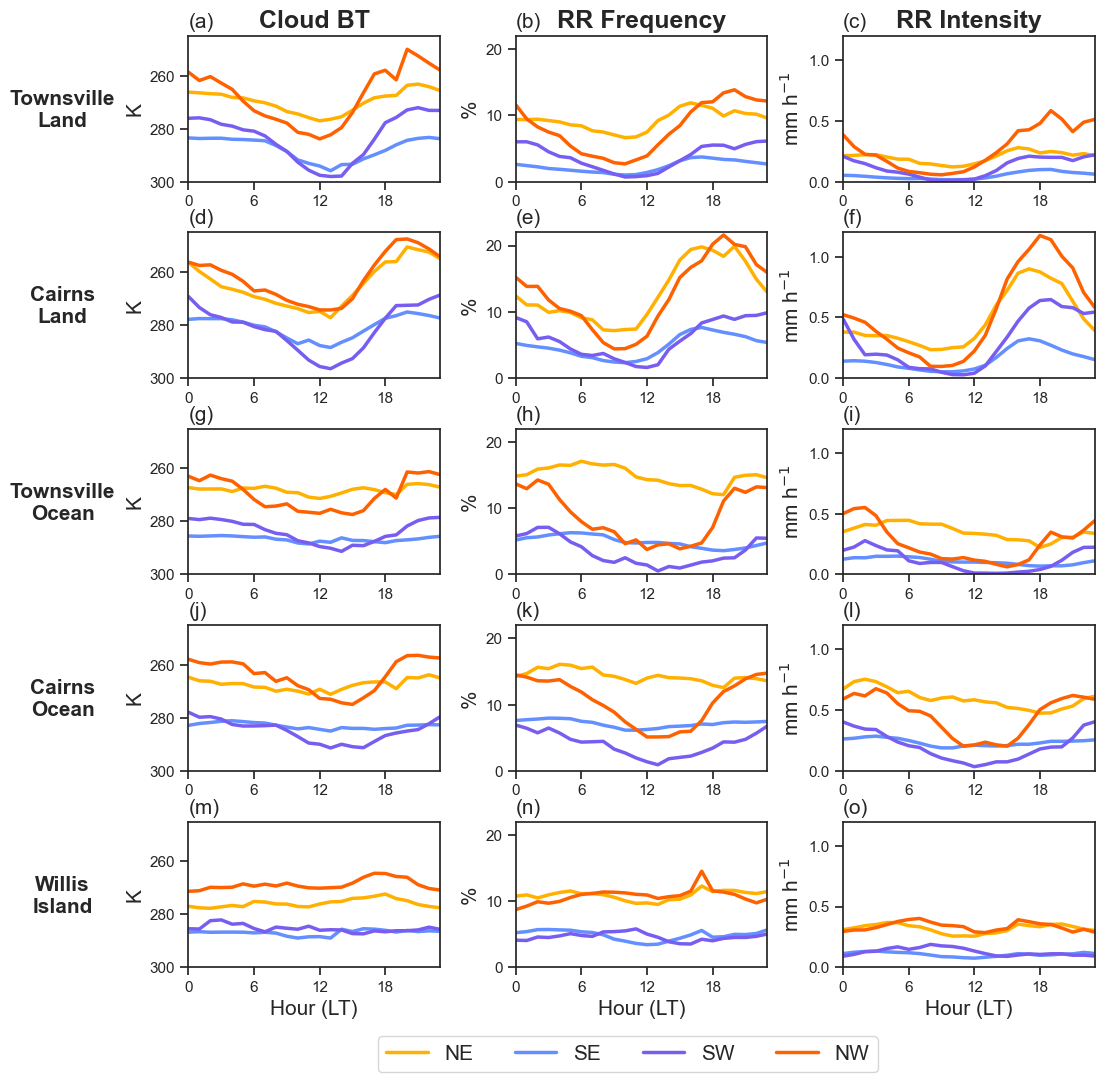

In [10]:
diurnal_cycle_plot(245, 300, 22, 1.2, data) #30,-30